<div align="center">

# El Ecosistema de la Programación en España: 
## Evolución, Interés y Demanda Laboral

</div>

Este estudio analiza la evolución de los **lenguajes de programación en España (2021-2025)** mediante la triangulación de tres fuentes clave: el **uso profesional** (Stack Overflow), el **interés de aprendizaje** (YouTube) y la **demanda laboral** (InfoJobs). 

El análisis pone especial foco en cómo la **Inteligencia Artificial** está reconfigurando la participación de la comunidad y acelerando la adopción de nuevas tecnologías, permitiendo distinguir entre el *hype* mediático y la realidad del mercado laboral nacional.

In [419]:
import pandas as pd
import numpy as np
import os

## Importación de datos

### Stack Overflow
Importamos los datos de las encuestas anuales de Stack Overflow desde [su repositorio oficial](https://survey.stackoverflow.co/).

Comenzamos analizando el primer CSV para entender la estructura de los datos y el formato de su contenido.

In [420]:
df_stack_21 = pd.read_csv("data/stack-overflow-developer-survey-2021.csv")
df_stack_21.head()

,ResponseId,MainBranch,Employment,Country,US_State,UK_Country,EdLevel,Age1stCode,LearnCode,YearsCode,YearsCodePro,DevType,OrgSize,Currency,CompTotal,CompFreq,LanguageHaveWorkedWith,LanguageWantToWorkWith,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,PlatformHaveWorkedWith,PlatformWantToWorkWith,WebframeHaveWorkedWith,WebframeWantToWorkWith,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,OpSys,NEWStuck,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOComm,NEWOtherComms,Age,Gender,Trans,Sexuality,Ethnicity,Accessibility,MentalHealth,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Slovakia,NaN,NaN,"Secondary school (e.g. American high school, G...",18 - 24 years,Coding Bootcamp;Other online resources (ex: vi...,NaN,NaN,"Developer, mobile",20 to 99 employees,EUR European Euro,4800.0,Monthly,C++;HTML/CSS;JavaScript;Objective-C;PHP;Swift,Swift,PostgreSQL;SQLite,SQLite,NaN,NaN,Laravel;Symfony,NaN,NaN,NaN,NaN,NaN,PHPStorm;Xcode,Atom;Xcode,MacOS,Call a coworker or friend;Visit Stack Overflow...,Stack Overflow,Multiple times per day,Yes,A few times per month or weekly,"Yes, definitely",No,25-34 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Easy,62268.0
1,2,I am a student who is learning to code,"Student, full-time",Netherlands,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",7,NaN,NaN,NaN,NaN,NaN,NaN,JavaScript;Python,NaN,PostgreSQL,NaN,NaN,NaN,Angular;Flask;Vue.js,NaN,Cordova,NaN,Docker;Git;Yarn,Git,Android Studio;IntelliJ;Notepad++;PyCharm,NaN,Windows,Visit Stack Overflow;Google it,Stack Overflow,Daily or almost daily,Yes,Daily or almost daily,"Yes, definitely",No,18-24 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Easy,NaN
2,3,"I am not primarily a developer, but I write co...","Student, full-time",Russian Federation,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Assembly;C;Python;R;Rust,Julia;Python;Rust,SQLite,SQLite,Heroku,NaN,Flask,Flask,NumPy;Pandas;TensorFlow;Torch/PyTorch,Keras;NumPy;Pandas;TensorFlow;Torch/PyTorch,NaN,NaN,IPython/Jupyter;PyCharm;RStudio;Sublime Text;V...,IPython/Jupyter;RStudio;Sublime Text;Visual St...,MacOS,Visit Stack Overflow;Google it;Watch help / tu...,Stack Overflow;Stack Exchange,Multiple times per day,Yes,Multiple times per day,"Yes, definitely",Yes,18-24 years old,Man,No,Prefer not to say,Prefer not to say,None of the above,None of the above,Appropriate in length,Easy,NaN
3,4,I am a developer by profession,Employed full-time,Austria,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",11 - 17 years,NaN,NaN,NaN,"Developer, front-end",100 to 499 employees,EUR European Euro,NaN,Monthly,JavaScript;TypeScript,JavaScript;TypeScript,NaN,NaN,NaN,NaN,Angular;jQuery,Angular;jQuery,NaN,NaN,NaN,NaN,NaN,NaN,Windows,Call a coworker or friend;Visit Stack Overflow...,Stack Overflow,Daily or almost daily,Yes,Daily or almost daily,Neutral,No,35-44 years old,Man,No,Straight / Heterosexual,White or of European descent,I am deaf / hard of hearing,NaN,Appropriate in length,Neither easy nor difficult,NaN
4,5,I am a developer by profession,"Independent contractor, freelancer, or self-em...",United Kingdom of Great Britain and Northern I...,NaN,England,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5 - 10 years,Friend or family member,17,10,"Developer, desktop or enterprise applications;...","Just me - I am a freelancer, sole proprietor, ...",GBP\tPound sterling,NaN,NaN,Bash/Shell;HTML/CSS;Python;SQL,Bash/Shell;HTML/CSS;Python;SQL,Elasticsearch;PostgreSQL;Redis,Cassandra;Elasticsearch;PostgreSQL;Redis,Na

In [421]:
df_stack_21.info()


<class 'pandas.DataFrame'>
RangeIndex: 83439 entries, 0 to 83438
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ResponseId                    83439 non-null  int64  
 1   MainBranch                    83439 non-null  str    
 2   Employment                    83323 non-null  str    
 3   Country                       83439 non-null  str    
 4   US_State                      14920 non-null  str    
 5   UK_Country                    4418 non-null   str    
 6   EdLevel                       83126 non-null  str    
 7   Age1stCode                    83243 non-null  str    
 8   LearnCode                     82963 non-null  str    
 9   YearsCode                     81641 non-null  str    
 10  YearsCodePro                  61216 non-null  str    
 11  DevType                       66484 non-null  str    
 12  OrgSize                       60726 non-null  str    
 13  Currency    

### Filtrado por dedicación
Evaluamos el comportamiento de la muestra al filtrar la columna `MainBranch` (tipo de dedicación). 

Listamos las opciones disponibles y descartamos perfiles no profesionales, como programadores por hobby o exdesarrolladores, para centrar el estudio en el ámbito laboral.

In [422]:
# obtrener los distintos valores de la columna "MainBranch"
df_stack_21["MainBranch"].unique()

<StringArray>
[                                               'I am a developer by profession',
                                        'I am a student who is learning to code',
 'I am not primarily a developer, but I write code sometimes as part of my work',
                                                   'I code primarily as a hobby',
                      'I used to be a developer by profession, but no longer am',
                                                                 'None of these']
Length: 6, dtype: str

Descartamos 'I code primarily as a hobby', 'I used to be a developer... but no longer am' y 'None of these' y nos quedamos con los tipos que nos interesan

In [423]:

interesantes = [
    'I am a developer by profession',
    'I am a student who is learning to code',
    'I am not primarily a developer, but I write code sometimes as part of my work'
]

# Filtramos el DataFrame
df_stack_21_dedicacion = df_stack_21[df_stack_21['MainBranch'].isin(interesantes)]
df_stack_21_dedicacion.shape

(76760, 48)

### Filtrado geográfico
Asimismo, aplicamos un filtro por país para segmentar los datos exclusivamente a **España**.

In [424]:
df_stack_dedicacion_spain_2021 = df_stack_21_dedicacion[df_stack_21_dedicacion["Country"].values == "Spain"]
print(df_stack_dedicacion_spain_2021.shape)

(1407, 48)


### Carga masiva y estandarización
Importamos el resto de datasets de Stack Overflow y verificamos su evolución temporal; se observa un aumento progresivo en el número de columnas para adaptarse a los cambios del entorno tecnológico.

In [425]:
df_stack_22 = pd.read_csv("data/stack-overflow-developer-survey-2022.csv")
df_stack_23 = pd.read_csv("data/stack-overflow-developer-survey-2023.csv")
df_stack_24 = pd.read_csv("data/stack-overflow-developer-survey-2024.csv")
df_stack_25 = pd.read_csv("data/stack-overflow-developer-survey-2025.csv")

C:\Users\jlalo\AppData\Local\Temp\ipykernel_12452\2924736885.py:4: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stack_25 = pd.read_csv("data/stack-overflow-developer-survey-2025.csv")


In [426]:
print(df_stack_22.shape)
print(df_stack_23.shape)
print(df_stack_24.shape)
print(df_stack_25.shape)

(73268, 79)
(89184, 84)
(65437, 114)
(49191, 172)


Hacemos el mismo proceso con el resto de datasets para filtra los datos que nos interesan.

In [427]:
#hacemos el mismo proceso de filtrado sobre dedicación y país para los otros años

years = [2022, 2023, 2024, 2025]
array_dfs = [df_stack_22, df_stack_23, df_stack_24, df_stack_25]

for year, df in zip(years, array_dfs):
    df_dedicacion = df[df['MainBranch'].isin(interesantes)]
    globals()[f"df_stack_dedicacion_spain_{year}"] = df_dedicacion[df_dedicacion["Country"].values == "Spain"]

Seleccionamos las comunas que nos pueden resultar interesantes para nuestro caso de estudio.

Definimos una función para **estandarizar y unificar** los datasets. Esta función automatiza la importación, el filtrado de perfiles y el renombre de columnas para facilitar su manejo. Gracias a este enfoque modular, es posible ampliar el estudio simplemente añadiendo nuevos archivos al directorio.

Despues creamos una función de filtrado de pais, de esta forma podemos tener un DataFrame global y otro del pais a nuestra eleccion, en este caso, y por defecto, seria "Spain".

In [428]:
# Lista de columnas maestras que queremos
# Columnas que vamos a extraer de cada año (si existen)
columnas_interes = {
    'MainBranch': 'Dedicacion',
    'Country': 'Pais',
    'Age' : 'Edad',
    'YearsCodePro': 'Años_programando',
    'LanguageHaveWorkedWith': 'Lenguajes_uso',
    'LanguageWantToWorkWith': 'Lenguajes_deseo',
    'LearnCode': 'Metodo_aprendizaje',
    'LearnCodeOnline': 'Metodo_aprendizaje_online',
    'DevType': 'Categoria_Profesional',
    'ConvertedCompYearly': 'Salario_anual',
    'AISentiment': 'IA_sentimiento',
    'AIToolCurrentlyUsing': 'IA_herramientas',
    'AIAgentExternal': 'IA_herramientas_Externas'
}

dedicaciones = {
    'I am a developer by profession': 'profesional',
    'I am a student who is learning to code': 'estudiante',
    'I am not primarily a developer, but I write code sometimes as part of my work': 'ocasional'
}

# Función para cargar y estandarizar cada año, quedándonos solo con las columnas de interés y filtrando por dedicación
def load_and_standardize(year_file, year_label):
    df = pd.read_csv(year_file, low_memory=False)
    existing_cols = [c for c in columnas_interes.keys() if c in df.columns] # Solo nos quedamos con las columnas que existen en columnas_interes
    df = df[existing_cols].copy()
    df.rename(columns=columnas_interes, inplace=True)
    #filtramos por dedicación para reducir el tamaño del DataFrame
    df = df[df['Dedicacion'].isin(dedicaciones.keys())]
    #aprovechamos este punto para cambiar el dato de esta columna para acortar el contenido
    df['Dedicacion'] = df['Dedicacion'].map(dedicaciones)
    df['Year'] = year_label
    return df

# Función para filtrar por país
def filter_by_country(df, country="Spain"):
    return df[df['Pais'].values == country]

years = [2021, 2022, 2023, 2024, 2025]
dfs = [load_and_standardize(f"data/stack-overflow-developer-survey-{y}.csv", y) for y in years]

Finalmente, creamos los DataFrames maestros: `df_master_total` para el análisis global y `df_master` para el análisis específico de España.

In [429]:
df_master_total = pd.concat(dfs, axis=0, ignore_index=True)
df_master = filter_by_country(df_master_total, "Spain")

In [430]:
print(f"totales: {df_master_total.shape}")
print(f"filtrados por país: {df_master.shape}")

totales: (290972, 12)
filtrados por país: (5751, 12)


In [431]:
df_master.head()

,Dedicacion,Pais,Edad,Años_programando,Lenguajes_uso,Lenguajes_deseo,Metodo_aprendizaje,Categoria_Profesional,Salario_anual,Year,Metodo_aprendizaje_online,IA_herramientas_Externas
10,profesional,Spain,25-34 years old,5,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,C++;Clojure;JavaScript;Node.js;Rust;SQL;TypeSc...,"Other online resources (ex: videos, blogs, etc...","Developer, back-end",46482.0,2021,NaN,NaN
59,profesional,Spain,35-44 years old,10,Bash/Shell;JavaScript;Node.js;TypeScript,JavaScript;Node.js;Python;TypeScript,School,"Developer, back-end",58373.0,2021,NaN,NaN
70,profesional,Spain,18-24 years old,NaN,C#;Go;Java;Python,C++;Clojure;Go;Rust,Online Courses or Certification,"Developer, back-end",21620.0,2021,NaN,NaN
98,profesional,Spain,25-34 years old,8,HTML/CSS;Java;JavaScript;Node.js;Python;SQL,HTML/CSS;Java;JavaScript;Node.js;Python;SQL;Ty...,Coding Bootcamp;School,"Developer, full-stack;Developer, back-end;Prod...",38915.0,2021,NaN,NaN
242,profesional,Spain,35-44 years old,13,HTML/CSS;Java;JavaScript;Node.js;SQL,HTML/CSS;Java;JavaScript;Node.js;Python;SQL,Other (please specify):,"Developer, full-stack",NaN,2021,NaN,NaN


#### Análisis de lenguajes
Identificamos los lenguajes únicos en las columnas de uso y deseo (donde los valores están delimitados por `;`).

Generamos un diccionario de frecuencias para contabilizar las menciones de cada tecnología.

In [432]:
# creamos una lista de los lenguajes Unicos en las columnas de usados y deseados
languages_usados = df_master['Lenguajes_uso'].dropna().str.split(';').explode().unique()
languages_deseados = df_master['Lenguajes_deseo'].dropna().str.split(';').explode().unique()
total_languages = set(languages_usados) | set(languages_deseados)

In [433]:
#guardamos en un diccionario los lenguajes más populares contando las veces en salen en los lenguajes usados y deseados
used_languages = {}
desired_languages = {}
popular_languages = {}
for lang in total_languages:
    # 1. Procesamos la columna de uso: separamos por ';' y convertimos cada lenguaje en una fila y contamos las apariciones de cada lenguaje.
    conteo_uso = (df_master['Lenguajes_uso']
                .dropna() # eliminamos los NaN para evitar errores al hacer el split
                .str.split(';') # definimos el separador para evitar que un lenguaje como "C#" se divida en "C" y "#", JavaScript en "Java" y "Script", etc.
                .explode() # convertimos cada lenguaje en una fila
                .value_counts()) 

    # 2. Procesamos la columna de deseo: lo mismo
    conteo_deseo = (df_master['Lenguajes_deseo']
                    .dropna()
                    .str.split(';')
                    .explode()
                    .value_counts())
    used_languages[lang] = conteo_uso.get(lang, 0)
    desired_languages[lang] = conteo_deseo.get(lang, 0)
    popular_languages[lang] = used_languages[lang] + desired_languages[lang]
# ordenamos el diccionario por el número de menciones
desired_languages = dict(sorted(desired_languages.items(), key=lambda item: item[1], reverse=True))
used_languages = dict(sorted(used_languages.items(), key=lambda item: item[1], reverse=True))
popular_languages = dict(sorted(popular_languages.items(), key=lambda item: item[1], reverse=True))

    

Imprimimos el resultado para analizar el contenido y descubrimos que hay que depurar algún dato.

In [434]:
for lang, count in list(popular_languages.items())[:15]:
    print(f"{lang}: {count} menciones")

JavaScript: 5961 menciones
SQL: 4987 menciones
Python: 4892 menciones
HTML/CSS: 4869 menciones
TypeScript: 3999 menciones
Java: 3333 menciones
C#: 2240 menciones
PHP: 2034 menciones
Go: 1735 menciones
C++: 1668 menciones
Rust: 1659 menciones
Bash/Shell (all shells): 1625 menciones
Kotlin: 1424 menciones
C: 1404 menciones
Bash/Shell: 1293 menciones


Tras una inspección inicial de los resultados, detectamos la necesidad de **depurar y normalizar** los datos. Por ejemplo, conceptos duplicados como "Bash/Shell" y "Bash/Shell (all shells)", o variaciones de capitalización como "COBOL" y "Cobol", han sido unificados para garantizar la integridad del conteo.

In [435]:
# creamos un diccionario con los cambios que queremos hacer para unificar los nombres de los lenguajes
mapeo_terms = {
    'Bash/Shell (all shells)': 'Bash/Shell',
    'COBOL': 'Cobol'
}
#definiendo una función para reemplazar los nombres de los lenguajes en ambas columnas
def normalizar_lenguajes_col(serie, mapeo):
    return (
        serie.fillna('')
             .str.split(';')
             .apply(lambda xs: ';'.join([mapeo.get(x.strip(), x.strip()) for x in xs if x.strip()]))
             .replace('', np.nan)
    )

df_master['Lenguajes_uso'] = normalizar_lenguajes_col(df_master['Lenguajes_uso'], mapeo_terms)
df_master['Lenguajes_deseo'] = normalizar_lenguajes_col(df_master['Lenguajes_deseo'], mapeo_terms)

# importante: recalcular tras normalizar para que esos lenguajes no sigan apareciendo como distintos
languages_usados = df_master['Lenguajes_uso'].dropna().str.split(';').explode().unique()
languages_deseados = df_master['Lenguajes_deseo'].dropna().str.split(';').explode().unique()
total_languages = set(languages_usados) | set(languages_deseados)

Volvemos a contar para verificar que el cambio se ha aplicado correctamente

In [436]:
popular_languages = {}
for lang in total_languages:
    # 1. Procesamos la columna de uso: separamos por ';' y convertimos cada lenguaje en una fila
    conteo_uso = (df_master['Lenguajes_uso']
                .dropna() # eliminamos los NaN para evitar errores al hacer el split
                .str.split(';') # definimos el separador para evitar que un lenguaje como "C#" se divida en "C" y "#", JavaScript en "Java" y "Script", etc.
                .explode() # convertimos cada lenguaje en una fila
                .value_counts())

    # 2. Procesamos la columna de deseo: lo mismo
    conteo_deseo = (df_master['Lenguajes_deseo']
                    .dropna()
                    .str.split(';')
                    .explode()
                    .value_counts())
    used_languages[lang] = conteo_uso.get(lang, 0)
    desired_languages[lang] = conteo_deseo.get(lang, 0)
    popular_languages[lang] = used_languages[lang] + desired_languages[lang]
# ordenamos el diccionario por el número de menciones
desired_languages = dict(sorted(desired_languages.items(), key=lambda item: item[1], reverse=True))
used_languages = dict(sorted(used_languages.items(), key=lambda item: item[1], reverse=True))
popular_languages = dict(sorted(popular_languages.items(), key=lambda item: item[1], reverse=True))
for lang, count in list(popular_languages.items())[:15]:
    print(f"{lang}: {count} menciones")

JavaScript: 5961 menciones
SQL: 4987 menciones
Python: 4892 menciones
HTML/CSS: 4869 menciones
TypeScript: 3999 menciones
Java: 3333 menciones
Bash/Shell: 2918 menciones
C#: 2240 menciones
PHP: 2034 menciones
Go: 1735 menciones
C++: 1668 menciones
Rust: 1659 menciones
Kotlin: 1424 menciones
C: 1404 menciones
PowerShell: 878 menciones


### El "Hype Ratio": Uso vs. Deseo
Creamos un nuevo DataFrame para comparar la popularidad actual frente a la proyección futura mediante el **Hype Ratio** (Cociente entre menciones de *deseo* y menciones de *uso*).

In [437]:
df_popular_languages = pd.DataFrame({
    'Lenguaje': list(popular_languages.keys()), # con keys() nos aseguramos de mantener el mismo orden en los tres diccionarios
    'Uso': [used_languages[lang] for lang in popular_languages.keys()],
    'Deseo': [desired_languages[lang] for lang in popular_languages.keys()],
    'Hype_Ratio': [desired_languages[lang] / used_languages[lang] if used_languages[lang] > 0 else 0 for lang in popular_languages.keys()]
})
df_popular_languages.sort_values(by='Hype_Ratio', ascending=False, inplace=True)
df_popular_languages


,Lenguaje,Uso,Deseo,Hype_Ratio
54,Mojo,1,8,8.000000
34,Zig,19,137,7.210526
49,Gleam,5,21,4.200000
51,APL,3,12,4.000000
33,Julia,38,124,3.263158
11,Rust,403,1256,3.116625
56,Zephyr,1,3,3.000000
36,F#,37,105,2.837838
35,Solidity,43,102,2.372093
42,OCaml,21,46,2.190476


En este punto imprimimos el listado ordenados deseo para analizar cuales son los lenguajes con mas interes de aprendizaje. 

* **Lenguajes Emergentes:** Tecnologías como **Rust, Go y Dart** presentan un Hype Ratio muy alto. Esto indica que, aunque su base de usuarios actual es pequeña, generan un gran interés y potencial de crecimiento.
* **Lenguajes Consolidados:** **JavaScript, Python y Java** muestran ratios cercanos a 1, reflejando equilibrio y estabilidad entre su fuerza laboral actual y los nuevos interesados.
* **Lenguajes en Declive:** Tecnologías como **PHP o Cobol** presentan los ratios más bajos, sugiriendo que su base de usuarios está disminuyendo y no logran atraer a nuevos programadores.

In [438]:
df_popular_languages.sort_values(by='Deseo', ascending=False, inplace=True)
df_popular_languages.head(10)


,Lenguaje,Uso,Deseo,Hype_Ratio
0,JavaScript,3641,2320,0.637188
2,Python,2601,2291,0.880815
1,SQL,2989,1998,0.668451
4,TypeScript,2074,1925,0.928158
3,HTML/CSS,2967,1902,0.641052
11,Rust,403,1256,3.116625
5,Java,2163,1170,0.540915
9,Go,584,1151,1.970890
6,Bash/Shell,1803,1115,0.618414
7,C#,1293,947,0.732405


### Google Trends (YouTube)

Incorporamos datos de Google Trends filtrados por el país (España) y la categoría de búsqueda en **YouTube**. Esto nos permite medir el interés educativo y de consumo de contenido de los últimos 5 años.

![Filtro de Google Trends](img/filtro-google-trends.png)


In [439]:
df_trends = pd.read_csv("data/tendencias_lenguajes.csv")
df_trends.head()

,Time,JavaScript,SQL,Python,HTML,TypeScript,Java,C Sharp,PHP
0,2021-04-01,16,8,28,11,0,19,5,8
1,2021-05-01,16,10,25,11,0,23,6,8
2,2021-06-01,15,7,27,12,0,19,5,6
3,2021-07-01,14,7,25,9,0,15,5,5
4,2021-08-01,11,6,24,7,0,18,5,6


Normalizamos los nombres de columnas (ej. "C Sharp" a "C#") para asegurar la compatibilidad con los datos de Stack Overflow.

In [440]:
#renombamos la colmna "C Sharp" a "C#" para que coincida con el nombre del lenguaje en nuestro DataFrame
df_trends.rename(columns={'C Sharp': 'C#'}, inplace=True)
df_trends.rename(columns={'HTML': 'HTML/CSS'}, inplace=True)
df_trends.head()

,Time,JavaScript,SQL,Python,HTML/CSS,TypeScript,Java,C#,PHP
0,2021-04-01,16,8,28,11,0,19,5,8
1,2021-05-01,16,10,25,11,0,23,6,8
2,2021-06-01,15,7,27,12,0,19,5,6
3,2021-07-01,14,7,25,9,0,15,5,5
4,2021-08-01,11,6,24,7,0,18,5,6


## Visualización de datos

### Participación: España vs. Mundo
Analizamos el volumen de respuestas totales frente a las obtenidas en España. Se observa que, con el auge de los **LLMs (Large Language Models)**, el número de encuestas de Stack Overflow ha caído drásticamente.

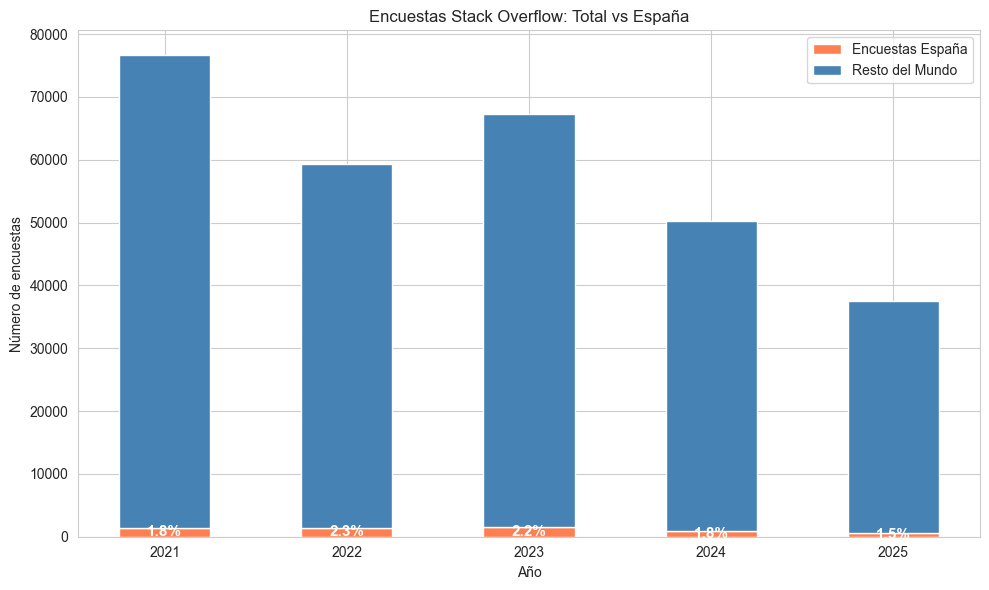

In [441]:
import matplotlib.pyplot as plt

df_plot = df_master_total.groupby('Year').size().reset_index(name='Total_Encuestas') #contamos el número de encuestas por año
df_plot_spain = df_master.groupby('Year').size().reset_index(name='Encuestas_España') #contamos el número de encuestas por año para España
df_plot = df_plot.merge(df_plot_spain, on='Year', how='left') #hacemos un merge para juntar ambos DataFrames
df_plot['Resto_Mundo'] = df_plot['Total_Encuestas'] - df_plot['Encuestas_España'] #calculamos el número de encuestas del resto del mundo
df_plot['Porcentaje_España'] = (df_plot['Encuestas_España'] / df_plot['Total_Encuestas']) * 100 #calculamos el porcentaje de encuestas de España

fig, ax = plt.subplots(figsize=(10, 6)) #creamos la figura y el eje para el gráfico
x = range(len(df_plot))
width = 0.5

# Barra de España abajo
bars_spain = ax.bar(x, df_plot['Encuestas_España'], width, label='Encuestas España', color='coral')
# Barra del resto del mundo apilada encima
bars_resto = ax.bar(x, df_plot['Resto_Mundo'], width, bottom=df_plot['Encuestas_España'], label='Resto del Mundo', color='steelblue')

# Añadir el porcentaje dentro de las barras de España
for i, (bar, pct) in enumerate(zip(bars_spain, df_plot['Porcentaje_España'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f'{pct:.1f}%',
            ha='center', va='center', fontweight='bold', color='white', fontsize=11)

ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['Year'].astype(int))
ax.set_xlabel('Año')
ax.set_ylabel('Número de encuestas')
ax.legend()
ax.set_title('Encuestas Stack Overflow: Total vs España')
plt.tight_layout()
plt.show()

In [492]:
df_plot


,Year,Total_Encuestas,Encuestas_España,Resto_Mundo,Porcentaje_España
0,2021,76760,1407,75353,1.832986
1,2022,59301,1372,57929,2.313620
2,2023,67237,1470,65767,2.186296
3,2024,50207,922,49285,1.836397
4,2025,37467,580,36887,1.548029


Este descenso coincide con la pérdida de tráfico del sitio, ya que los usuarios ahora resuelven dudas directamente mediante IA.

 Históricamente, se aprecia una fase de crecimiento (2008-2014), una consolidación (hasta 2022) y un brusco descenso actual que devuelve a la comunidad a niveles de 2008.

![Evolución Stack Overflow](img/nuevas-consultas-Stack-Overflow.png)

Fuente de los datos: [Stack Exchange Data Explorer](https://data.stackexchange.com/)

Se aprecia una fase de crecimiento de 2008 a 2014, una segunda fase de consolidación hasta 2022 y por último un brusco descenso desde 2022 hasta hoy, coincidiendo con la aparicion de los grandes modelos de Lenguage como ChatGPT y volviendo a los niveles de su comienzo en 2008.

Tambien se aprecia que la participación de España en esta encuesta mundial es casi insignificante.

### Geolocalización de las respuestas

En esta gráfica de geolocalización podemos ver donde se ubican las respuestas detectando que la mayor participación, con diferencia, viene de Estados Unidos, seguido por la India, donde hay grandes centros de desarrollo, Alemania e Inglaterra.


In [442]:
# %pip install pycountry

In [495]:
import plotly.express as px
import pycountry

geo_df = df_master_total['Pais'].value_counts().reset_index()
geo_df.columns = ['Pais', 'Encuestas']

#la localización por paises "country names" va a ser deprecada por lo que comvertimos los nombres de los paises a los codigos ISO de cada país para usar "ISO-3" como locationmode
def get_iso3(country_name):
        try:
            return pycountry.countries.lookup(country_name).alpha_3  # lookup busca por nombre común/oficial, si no encuentra el país como "United States of America"
        except (LookupError, AttributeError, TypeError):
            return None

geo_df['ISO-3'] = geo_df['Pais'].apply(get_iso3)


fig = px.scatter_geo(geo_df, locations="ISO-3", locationmode="ISO-3",
                     size="Encuestas", 
                     hover_name="Pais",
                     hover_data={"ISO-3": False, "Encuestas": True},
                     color="Encuestas",
                     projection="natural earth",
                     title="Distribución geográfica de encuestados Stack Overflow",
                     height=800,
                     width=1200
                     )
fig.show()
#geo_df


In [494]:
geo_df.to_csv('distribucion_geografica_encuestados.csv', index=False)

### Evolución de los contenidos de la encuesta.

Analizamos si el incremento en el número de preguntas (columnas) de la encuesta aporta mayor profundidad. A partir de 2023, destaca la incorporación de secciones específicas sobre IA.

Lo guardamos en un df para luego poder imprimirlo en un grafico de barras mostrando el número de columnas por año

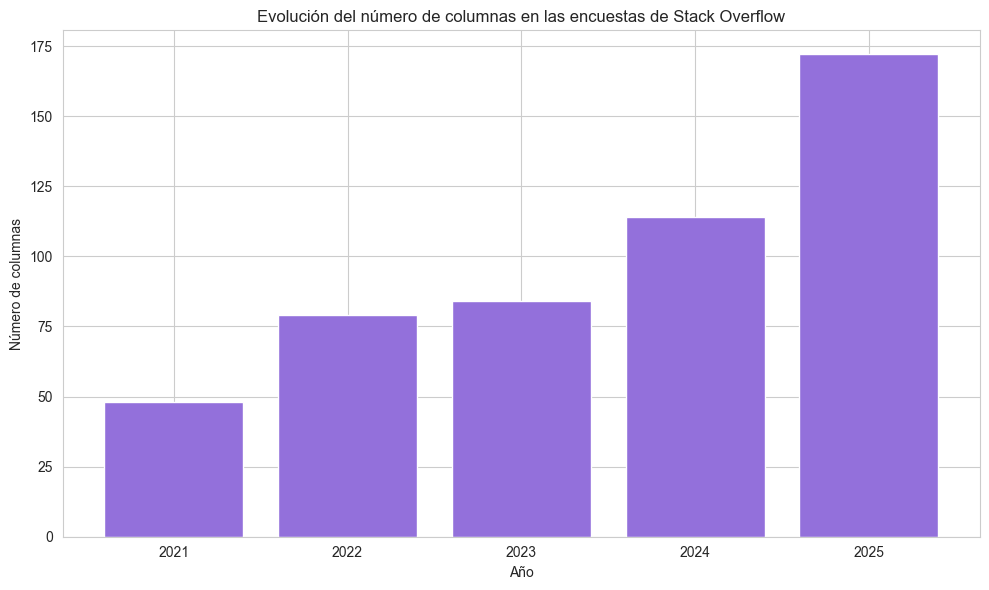

In [444]:
#creamos un DataFrame con el número de columnas de cada año para ver la evolución del número de preguntas en las encuestas a lo largo de los años   
df_columns = pd.DataFrame({
    'Año': [2021, 2022, 2023, 2024, 2025],
    'Número_Columnas': [len(df_stack_21.columns), len(df_stack_22.columns), len(df_stack_23.columns), len(df_stack_24.columns), len(df_stack_25.columns)]
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_columns['Año'], df_columns['Número_Columnas'], color='mediumpurple')
ax.set_xlabel('Año')
ax.set_ylabel('Número de columnas')
ax.set_title('Evolución del número de columnas en las encuestas de Stack Overflow')
plt.tight_layout()
plt.show()

Aquí podemos ver como la encueta se ha ido ampliando para concretar las preguntas, añadir nuevas preguntas como a partir de 2023 icormporando una sección sobre IA.


### Comparativa de lenguajes usados VS deseados

Ahora vamos a analizar la evolución de los lenguajes más populares a lo largo de los años para ver si hay tendencias claras de crecimiento o decrecimiento en su uso frentye al  deseo de aprender nuevos lenguajes.

En este punto ya tenemos filtrado el DataFrame con los datos de España y la dedicación, por lo que podemos analizar la evolución de los lenguajes más populares a lo largo de los años para ver si hay tendencias claras de crecimiento o decrecimiento en su uso y deseo

In [445]:
from plotly.offline import init_notebook_mode, iplot, plot

top10_items = list(used_languages.items())[:10]
pie1_list = [count for _, count in top10_items]
labels = list(used_languages.keys())[:10]


top10_items_to_learn = list(desired_languages.items())[:10]
pie2_list = [count for _, count in top10_items_to_learn]
labels2 = list(desired_languages.keys())[:10]

fig = {
    "data": [
        {
            "values": pie1_list,
            "labels": labels,
            "domain": {"x": [0, 0.45]},
            "name": "Más usados",
            "hoverinfo": "label+percent+name",
            "hole": 0.3,
            "type": "pie"
        },
        {
            "values": pie2_list,
            "labels": labels2,
            "domain": {"x": [0.55, 1]},
            "name": "Más deseados",
            "hoverinfo": "label+percent+name",
            "hole": 0.3,
            "type": "pie"
        },
    ],
    "layout": {
        "title": "Top 10 Lenguajes: Uso vs Deseo (España)",
        "annotations": [
            {"font": {"size": 16}, "showarrow": False, "text": "Más usados", "x": 0.18, "y": -0.1},
            {"font": {"size": 16}, "showarrow": False, "text": "Más deseados", "x": 0.82, "y": -0.1},
        ]
    }
}
iplot(fig)

**Hallazgos en la comparativa Uso vs. Deseo:**


Vemos que existe cierta correlación entre los lenguajes más usados y los más deseados, aunque también hay diferencias notables. 
Por ejemplo, Python es el cuarto lenguaje más usado y también el degundo más deseado, lo que indica una fuerte popularidad, demanda y proyección de este lenguaje.

JavaScript es el lenguaje más usado y tambien el que tiene más proyección debido al interés de los usuarios.

Por otro lado, lenguajes como Rust o Go pueden aparecer más alto en la lista de los más deseados que en la de los más usados, lo que sugiere un interés creciente en tecnologías emergentes.

Y por último lenguajes como PHP tienden a desaparecer debido a la falta de interes por parte de los usuario, a pesar de impulsar más del 75% de los sitios web conocidos, con CMS como Wordpress, Drupal o Joomla, eCommerce como Magento, WooCommerce y Prestashop o frameworks como Symfony y Laravel.

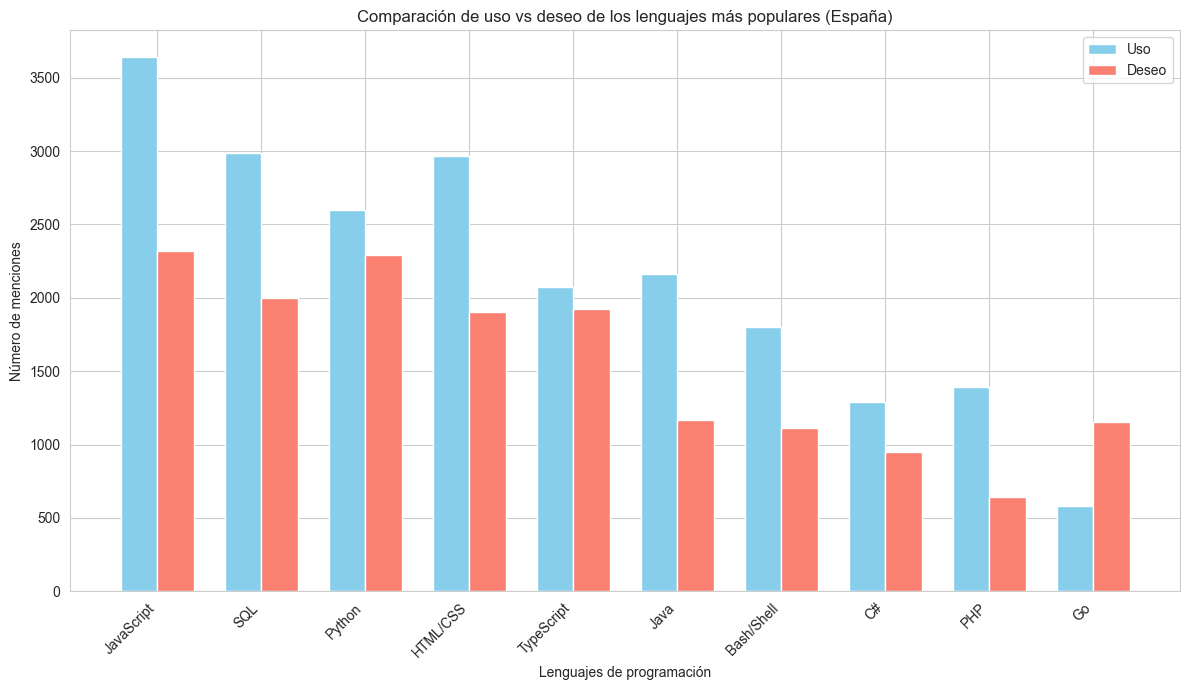

In [446]:
# ahora vamos a crear un gráfico de barras para comparar el número de menciones de los lenguajes más populares en uso y deseo
top10_populares = list(popular_languages.items())[:10]
lenguajes = [lang for lang, _ in top10_populares]
uso_counts = [used_languages[lang] for lang in lenguajes]
deseo_counts = [desired_languages[lang] for lang in lenguajes]
x = np.arange(len(lenguajes))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))
bars_uso = ax.bar(x - width/2, uso_counts, width, label='Uso', color='skyblue')
bars_deseo = ax.bar(x + width/2, deseo_counts, width, label='Deseo', color='salmon')
ax.set_xlabel('Lenguajes de programación')
ax.set_ylabel('Número de menciones')
ax.set_title('Comparación de uso vs deseo de los lenguajes más populares (España)')
ax.set_xticks(x)
ax.set_xticklabels(lenguajes, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

### Comparativa de lenguajes usados y deseados VS tendecias de busquedas en Youtube.

Para empezar creamos una función para generar un gráfico de evolución del uso y deseo con **valores absolutos** a lo largo de los años, comparándolo con su tendencia en Google Trends. De esta forma para pintar una nueva grafica de otro lenguaje sólo hay que llamarla pasandole el nombre del lenguaje

In [447]:
def plot_language_trends(lang_name, df_master, df_trends, years, ax=None):
    """Genera gráfico de evolución uso/deseo Stack Overflow vs Google Trends para un lenguaje."""
    df_trends['Time'] = pd.to_datetime(df_trends['Time'])
    
    evo_uso = [df_master[df_master['Year'] == year]['Lenguajes_uso'].fillna('').str.split(';').apply(lambda x, l=lang_name: l in x).sum() for year in years]
    evo_deseo = [df_master[df_master['Year'] == year]['Lenguajes_deseo'].fillna('').str.split(';').apply(lambda x, l=lang_name: l in x).sum() for year in years]
    
    years_dt = [pd.Timestamp(year=y, month=6, day=1) for y in years]
    
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Menciones Stack Overflow (España)', color='blue')
    ax.plot(years_dt, evo_uso, label=f'Uso {lang_name} (SO)', marker='o', color='blue')
    ax.plot(years_dt, evo_deseo, label=f'Deseo {lang_name} (SO)', marker='o', color='cyan')
    ax.tick_params(axis='y', labelcolor='blue')
    
    if lang_name in df_trends.columns:
        ax2 = ax.twinx()
        ax2.set_ylabel('Google Trends', color='red')
        ax2.plot(df_trends['Time'], df_trends[lang_name], label='Google Trends', color='red', alpha=0.6)
        ax2.tick_params(axis='y', labelcolor='red')
    
    ax.set_title(f'Valores absolutos de uso/deseo en Stack Overflow')
    ax.legend(loc='upper left')
    
    if standalone:
        plt.tight_layout()
        plt.show()

Para evitar el **sesgo por tamaño de la muestra** creamos la misma función pero normalizando el número de menciones por el total de encuestados de cada año para obtener un **valor porcentual** del uso y deseo en lugar del valor absoluto de la tabla anterior.


In [448]:
def plot_language_trends_pct(lang_name, df_master, df_trends, years, ax=None):
    df_trends['Time'] = pd.to_datetime(df_trends['Time'])
    
    evo_uso_pct = []
    evo_deseo_pct = []
    
    for year in years:
        # 1. Filtramos el DF por el año actual
        df_year = df_master[df_master['Year'] == year]
        total_encuestados = len(df_year)
        
        # 2. Contamos las menciones del lenguaje
        count_uso = df_year['Lenguajes_uso'].fillna('').str.split(';').apply(lambda x, l=lang_name: l in x).sum()
        count_deseo = df_year['Lenguajes_deseo'].fillna('').str.split(';').apply(lambda x, l=lang_name: l in x).sum()
        
        # 3. Normalizamos: calculamos el % sobre el total de ese año
        # Usamos una condición para evitar división por cero si un año no tiene datos
        if total_encuestados > 0:
            evo_uso_pct.append((count_uso / total_encuestados) * 100)
            evo_deseo_pct.append((count_deseo / total_encuestados) * 100)
        else:
            evo_uso_pct.append(0)
            evo_deseo_pct.append(0)
    
    years_dt = [pd.Timestamp(year=y, month=6, day=1) for y in years]
    
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.set_xlabel('Fecha')
    ax.set_ylabel('% Popularidad en Stack Overflow (España)', color='blue')
    ax.plot(years_dt, evo_uso_pct, label=f'% Uso {lang_name} (SO)', marker='o', color='blue', linewidth=2)
    ax.plot(years_dt, evo_deseo_pct, label=f'% Deseo {lang_name} (SO)', marker='o', linestyle='--', color='cyan')
    ax.tick_params(axis='y', labelcolor='blue')
    ax.set_ylim(0, max(max(evo_uso_pct), max(evo_deseo_pct)) * 1.2)
    
    # Google Trends
    if lang_name in df_trends.columns:
        ax2 = ax.twinx()
        ax2.set_ylabel('Interés Google Trends (YouTube)', color='red')
        ax2.plot(df_trends['Time'], df_trends[lang_name], label='Interés YouTube', color='red', alpha=0.4)
        ax2.tick_params(axis='y', labelcolor='red')
        ax2.set_ylim(0, 105)
    
    ax.set_title(f'Valores porcentuales de uso/deseo en Stack Overflow')
    ax.legend(loc='upper left')
    
    if standalone:
        plt.tight_layout()
        plt.show()

Finalmente creamos una función para mostrar las dos gráficas juntas para poder comparar el resultado de ambas.

In [449]:

def plot_language_trends_dual (lang_name, df_master, df_trends, years):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 6))
    plot_language_trends(lang_name, df_master, df_trends, years, ax=ax1)
    plot_language_trends_pct(lang_name, df_master, df_trends, years, ax=ax2)
    fig.suptitle(f'Evolución de {lang_name}: Uso/Deseo en Stack Overflow vs Interés en Google Trends', fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()

#### JavaScript

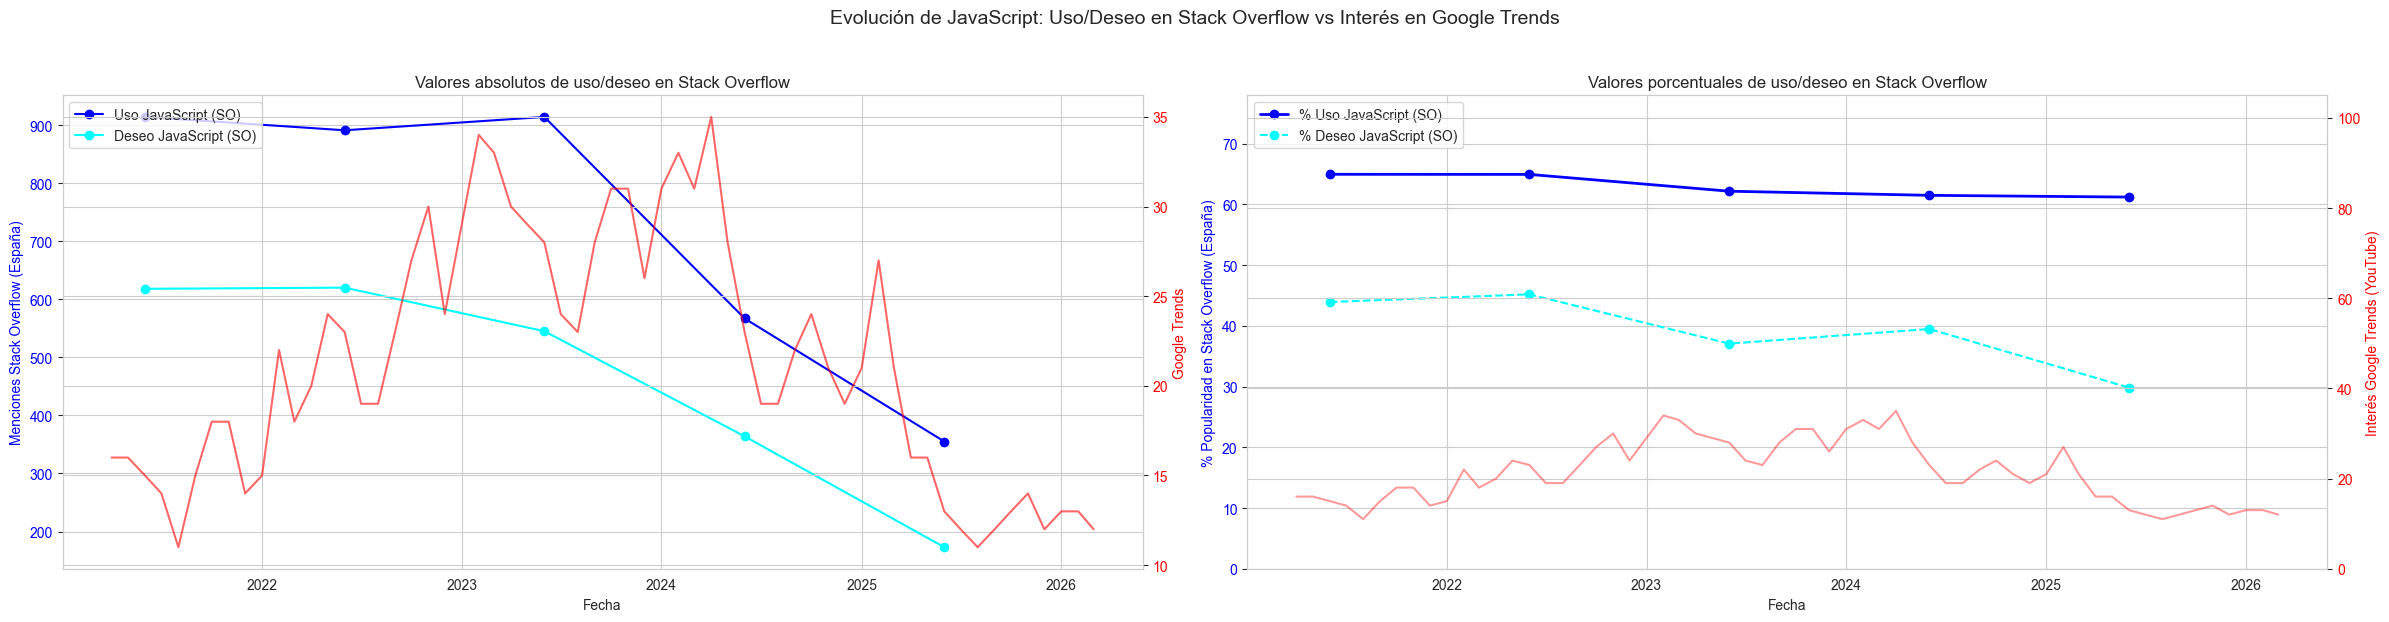

In [450]:
plot_language_trends_dual ('JavaScript', df_master, df_trends, years)


En este caso se observa claramente como la linea de deseo trascurre paralela a las búsqudedas de Youtube, estableciendo un clara relación con una tendencia descendente en anbos casos.

#### SQL

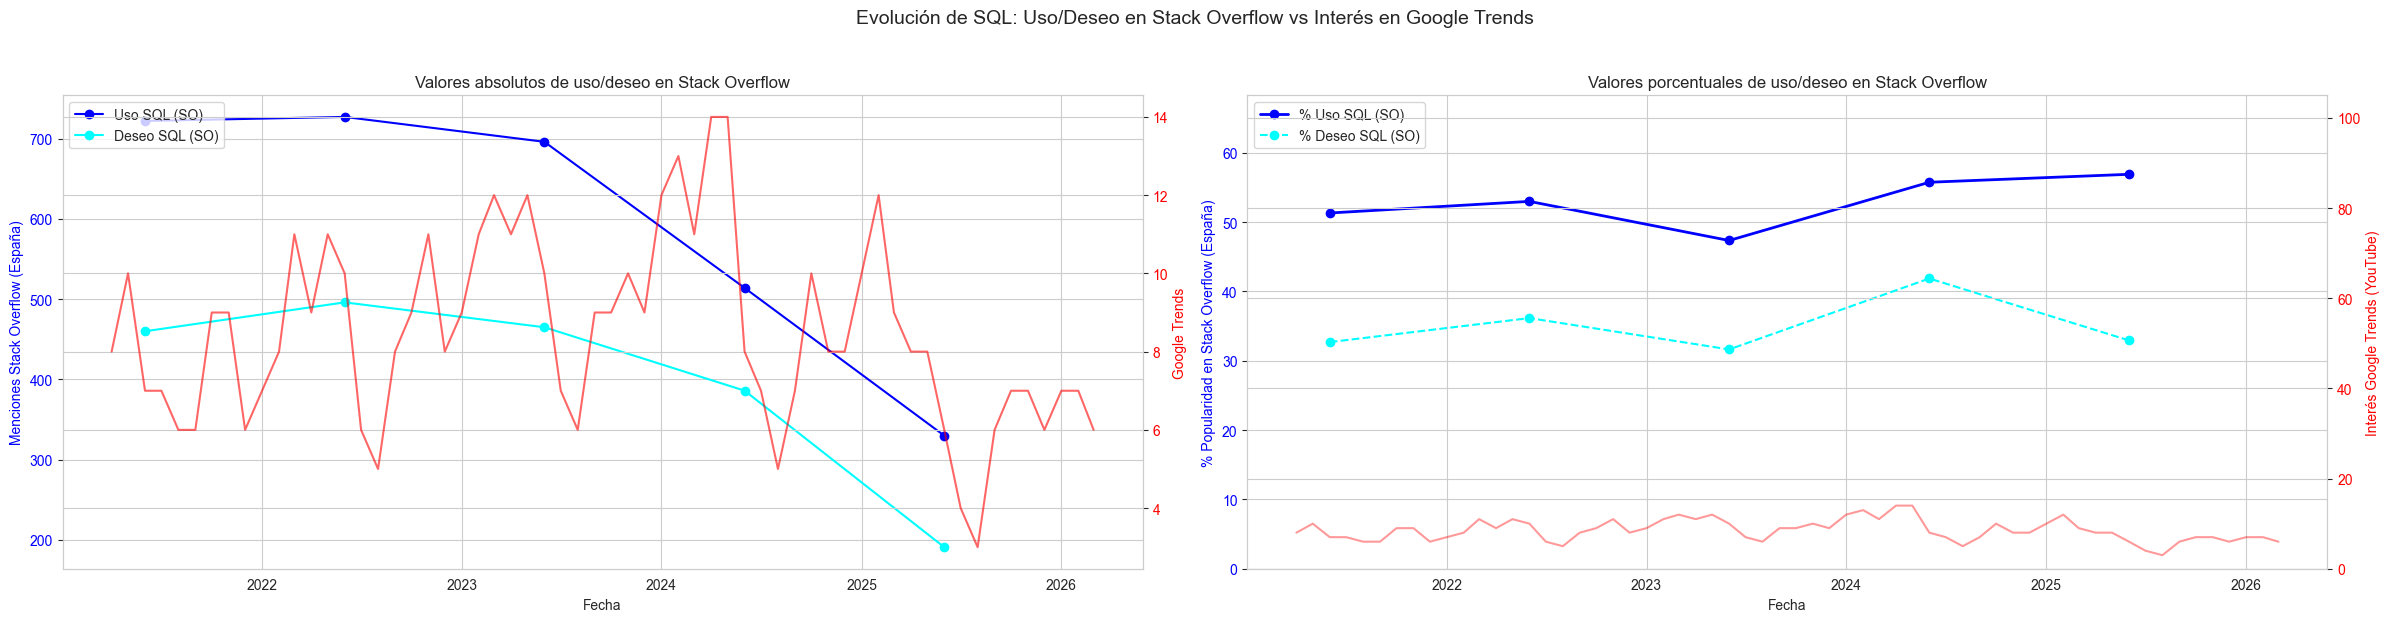

In [451]:
plot_language_trends_dual ('SQL', df_master, df_trends, years)


#### Python

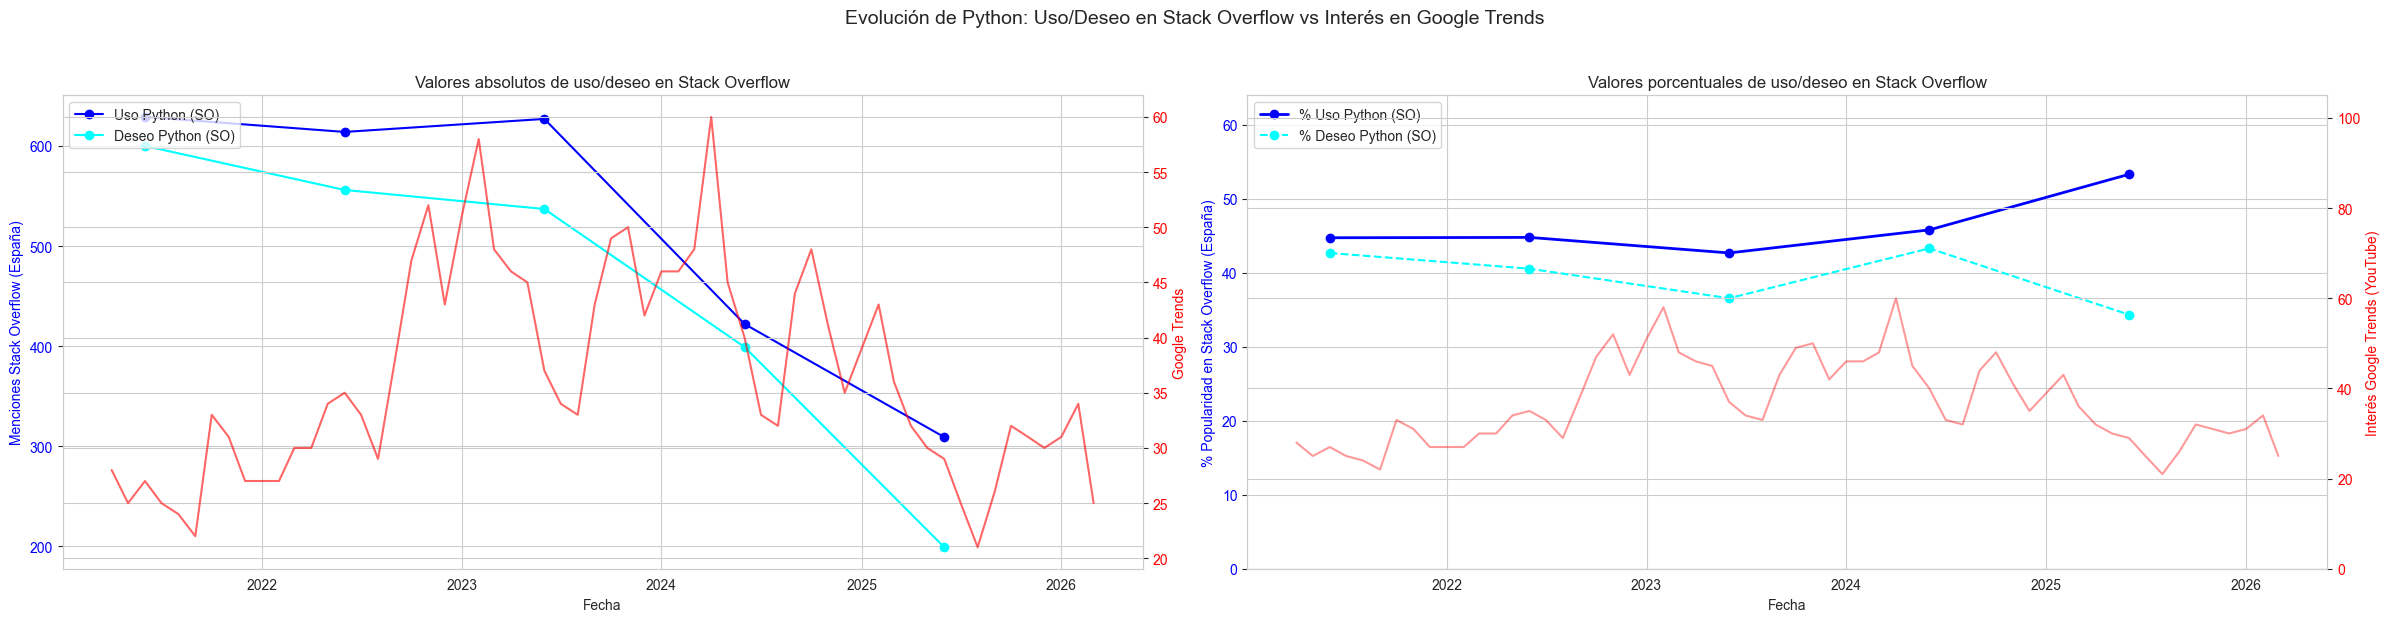

In [452]:
plot_language_trends_dual ('Python', df_master, df_trends, years)


Aqui tambien se aprecia un paralelismo sobre todo a partir de 2023 con una tendencia actual descendente.

#### HTML/CSS

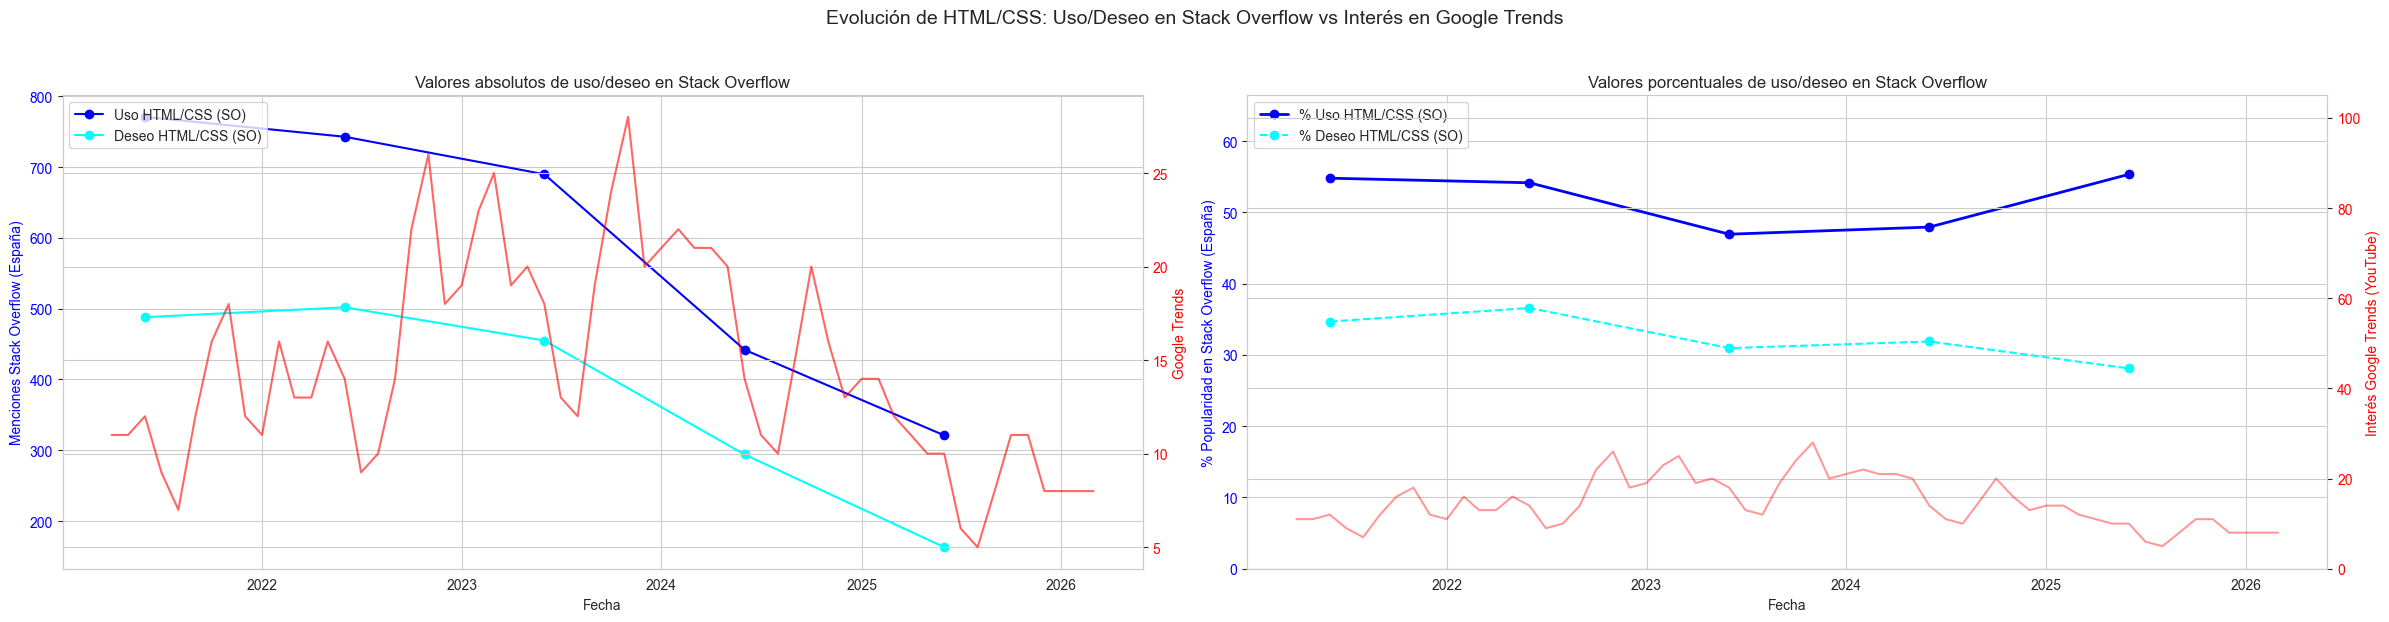

In [453]:
plot_language_trends_dual ('HTML/CSS', df_master, df_trends, years)

Al igual que los anteriores tambien se ven paralelismo entre el deseo y las busquedas aunque menos claramente debido, tal vez, a la estabilidad del lenguaje por su versatilidad.

#### TypeScript

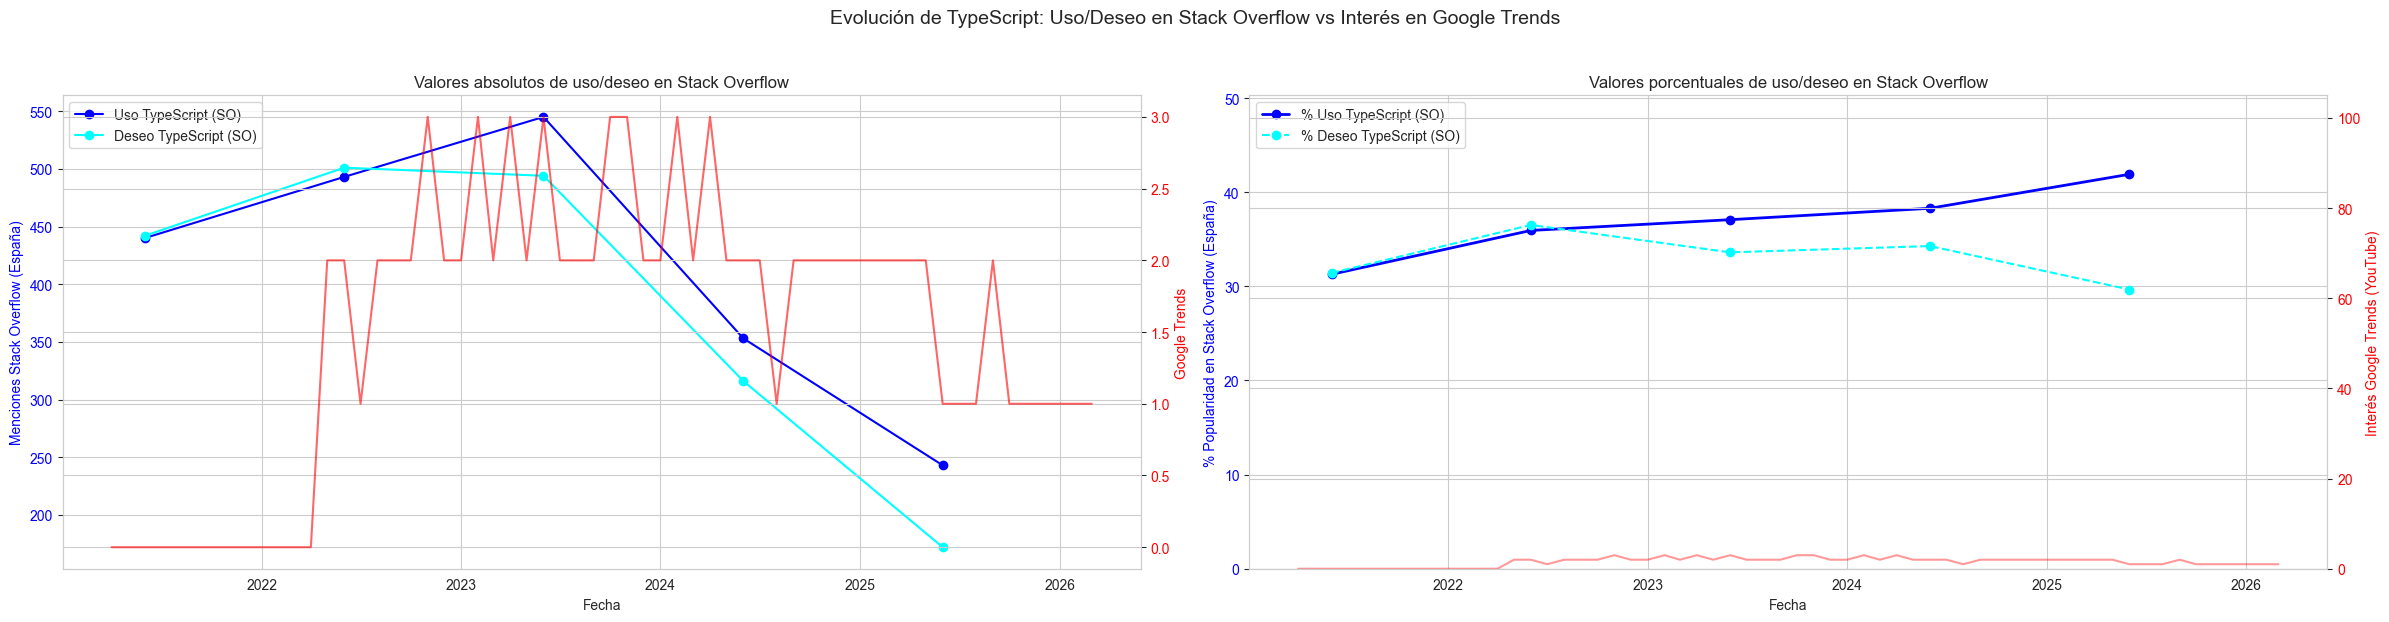

In [454]:
plot_language_trends_dual ('TypeScript', df_master, df_trends, years)

El caso de TypeScript es muy raro porque Google Trends muestra un numero de busquedas muy bajo, tal vez por un fallo en la categorización de las busquedas o integrado dentro de las búsquedas de JavaScript, escapando a las métricas de tendencia convencionales de YouTube.

#### Java

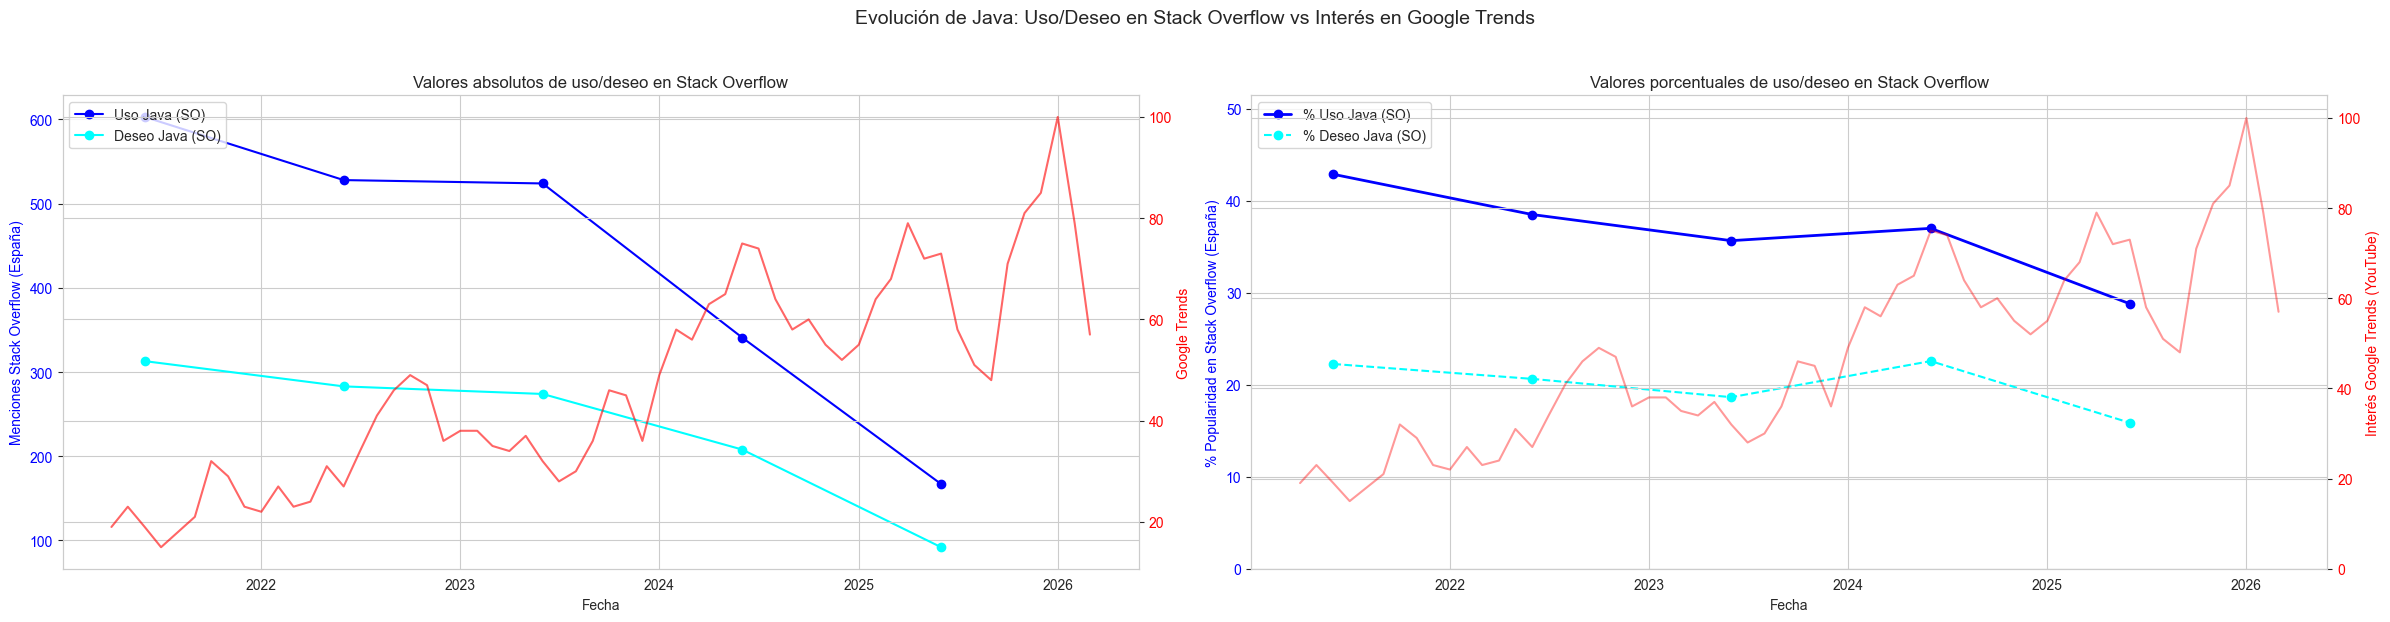

In [455]:
plot_language_trends_dual ('Java', df_master, df_trends, years)

#### C#

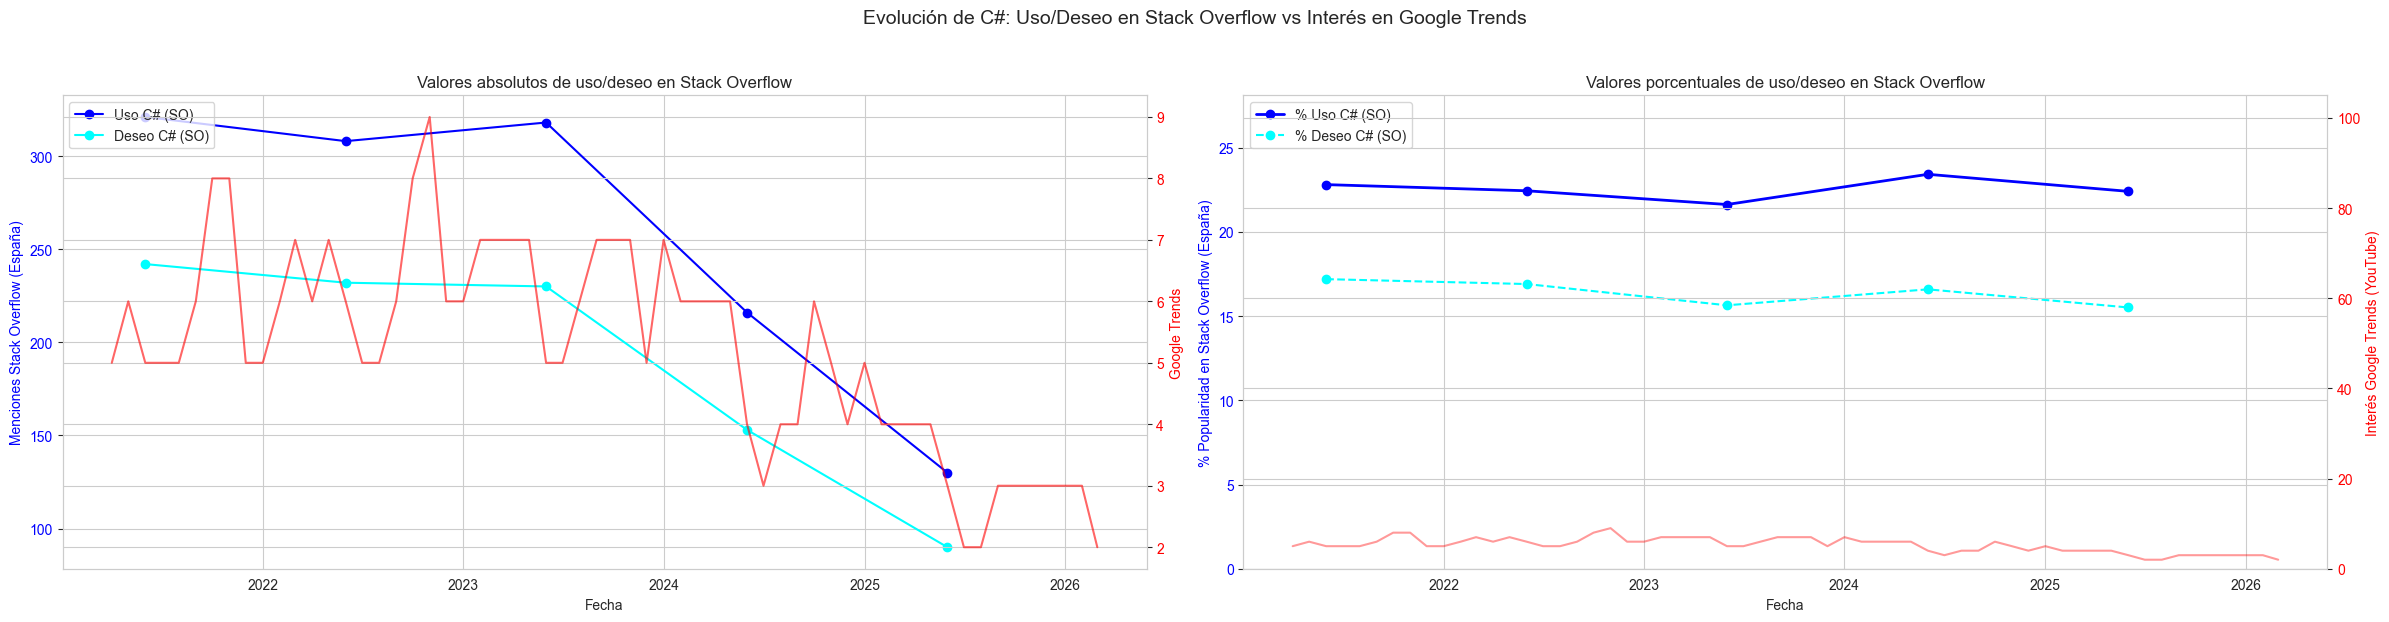

In [456]:
plot_language_trends_dual('C#', df_master, df_trends, years)

En este caso se aprecia lo mismo que en el caso de HTLM, muestra paralelismos pero por su estabilidad y bajo número de busquedas no es tan claramente apreciable con el caso de JavaScript.

#### PHP

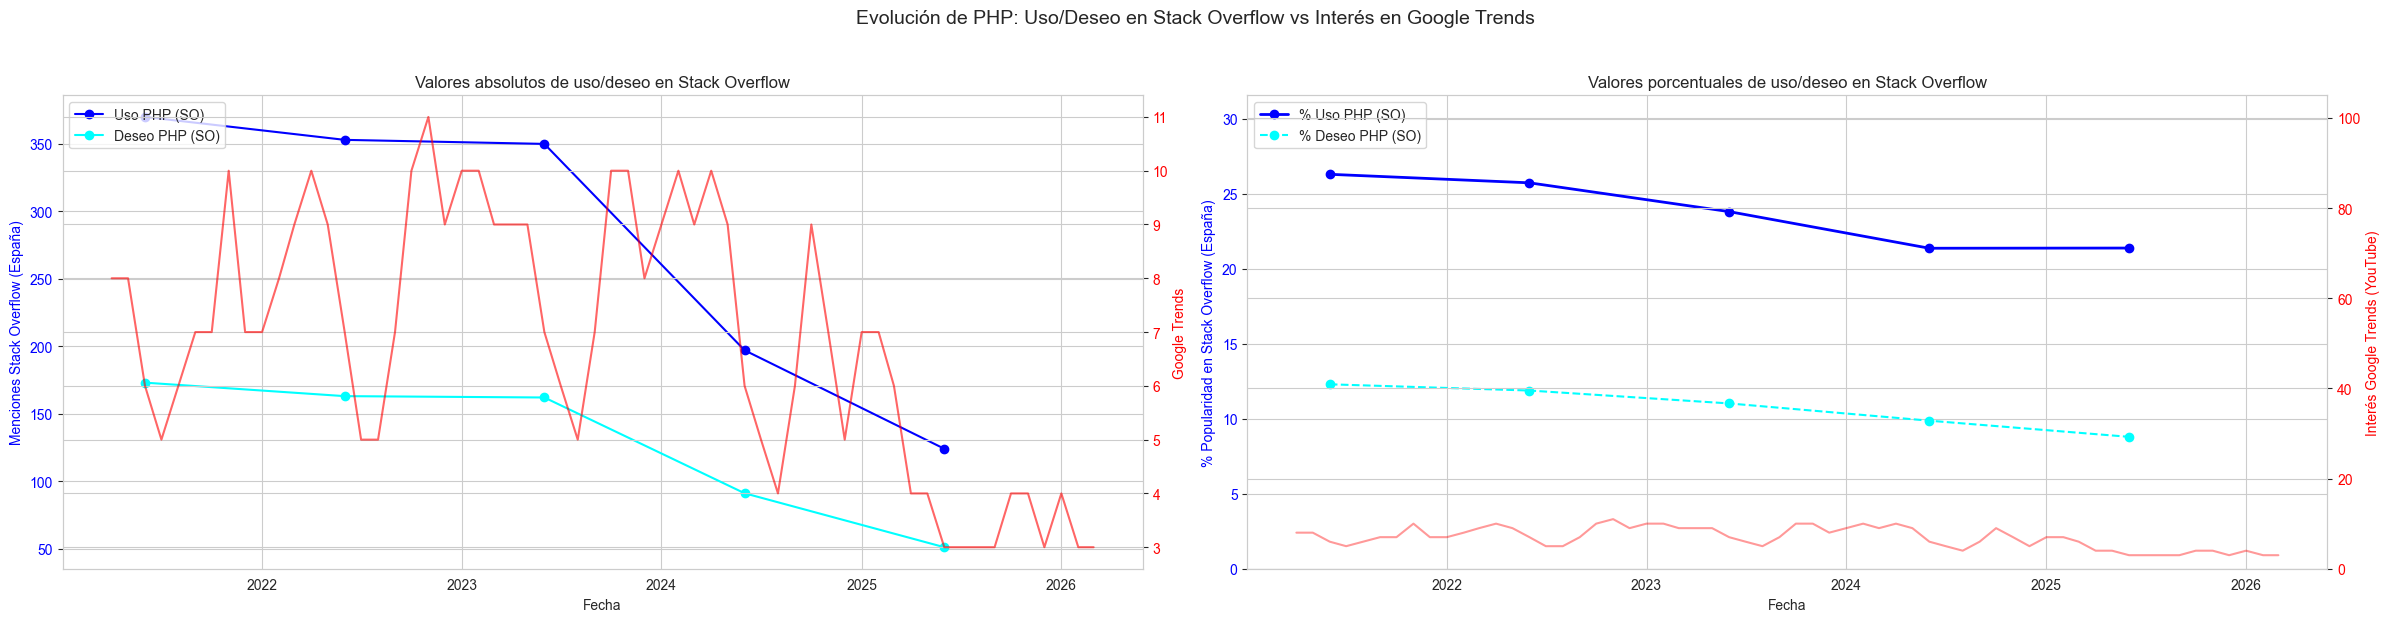

In [457]:
plot_language_trends_dual('PHP', df_master, df_trends, years)

En este último caso se ve claramete la tendencia constate de perdida de uso, interes por aprenderlo y bajada de búsquedas en youtube.

Si nos atenemos a las gráficas de valores absolutos vemos como a partir de 2023 y con la aparición de la IA hay un drástico descenso tanto del uso como de el deseo de aprender nuevos lenguajes, que casualmente cohincide con un descenso en las consultas sobre ese mismo lenguaje.

Esta conclusión se podria aplicar a los 8 lenguajes analizados a excepción de Java, que analizaremos más adelante.

Este descenso del uso y deseo es debido a la decadencia del sitio de referencia en el que hemos visto que desde 2023 ha descendido el número de respuestas a la encuesta.

En las gráficas de valores porcentuales vemos como las lineas de uso y deseo son mas estables en la mayoria de lenguajes aunque las lineas de tencias tienen las mismas tendencias.

### Análisis de Salarios por Lenguaje
Estudiamos la evolución salarial en España. Para evitar distorsiones causadas por valores atípicos (*outliers*) —como registros de salarios millonarios irreales—, utilizamos la **mediana** como medida de tendencia central en lugar de la media.

In [458]:
#metemos en un array unidimensional los 10 lenguajes más populares en uso , ya que son los que estan recibiendo un salario, pero solo el nombre del lenguaje
top_10_languages = df_popular_languages.sort_values(by='Uso', ascending=False)[:10]['Lenguaje'].values
top_10_languages

<StringArray>
['JavaScript',        'SQL',   'HTML/CSS',     'Python',       'Java',
 'TypeScript', 'Bash/Shell',        'PHP',         'C#',        'C++']
Length: 10, dtype: str

Al analizar los datos de salario anual vemos valores como 1102596.0, 492912.0 que no reflejan salarios reales asi que ponemos como valor de refencia la mediana en lugar de la media porque esos valores distorsionan la realidad.

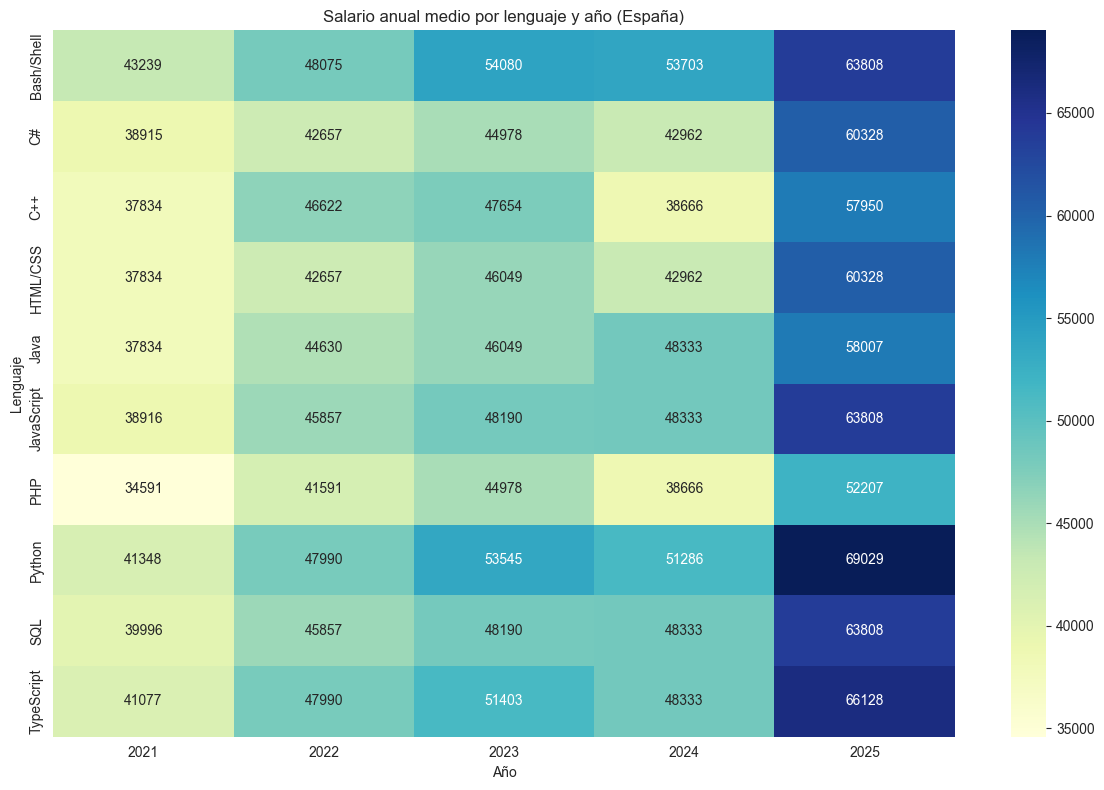

In [459]:
#vamos a crear un sns.heatmap con los lenguajes mas usados y el salario anual medio para cada lenguaje y entre los años
import seaborn as sns
#creamos un nuevo DataFrame con el salario anual medio para cada lenguaje de top_10_languages y para cada año de la lista 
#para conprobar 1º debe ver que algunao de los lenguajes de la lista top_10_languages esté en la columna de uso analizando toda la cadena de texto sepradeda por ';'
# y luego calcular el salario anual medio para cada lenguaje agupado por año
salarios_lenguajes = []
for lang in top_10_languages:
    mask = df_master['Lenguajes_uso'].fillna('').str.split(';').apply(lambda x, l=lang: l in x)
    df_lang = df_master[mask].copy()
    df_lang['Lenguajes_uso'] = lang
    salarios_lenguajes.append(df_lang[['Lenguajes_uso', 'Salario_anual', 'Year']])

df_top_10_languages = pd.concat(salarios_lenguajes, ignore_index=True).dropna(subset=['Salario_anual'])

plt.figure(figsize=(12, 8))
# en la aggfunc ponemos median para evitar que los valores atípicos distorsionen el gráfico, ya que el salario anual puede tener valores muy altos que no son representativos del salario típico de ese lenguaje
sns.heatmap(df_top_10_languages.pivot_table(index='Lenguajes_uso', columns='Year', values='Salario_anual', aggfunc='median'), annot=True, fmt=".0f", cmap="YlGnBu")
plt.xlabel('Año')
plt.ylabel('Lenguaje')
plt.title('Salario anual medio por lenguaje y año (España)')
plt.tight_layout()
plt.show()




**Resultados:**
* Lenguajes con alta demanda y "deseo" como **Python y TypeScript** presentan medianas salariales superiores y casualmente son tambien los que más interes por aprender suscitan.
* Tecnologías en declive de interés, como **PHP**, se sitúan en los rangos salariales más bajos.
* Es importante notar que tecnologías como **SQL o Bash** no suelen operar de forma aislada, sino como complementos que incrementan el valor de perfiles especializados en otros lenguajes.

### Análisis de Métodos de Aprendizaje Online

En este punto vamos a listar los distintas preferencias de formación online que aparecen en la columna `Metodo_aprendizaje_online` para seleccionar los que nos interesa para nuestro caso de estudio



In [460]:
# vamos a analizar la columna Metodo_aprendizaje_online
df_master['Metodo_aprendizaje_online'].value_counts()
#ahora vamos a recorrer los valores para separar por el delimitador ';', extraer los valores únicos y contar las menciones de cada método de aprendizaje online
metodos = df_master['Metodo_aprendizaje_online'].dropna().str.split(';')
metodos_exploded = metodos.explode()
metodos_exploded.value_counts()


Metodo_aprendizaje_online
Stack Overflow                                                 2281
Written Tutorials                                              1701
How-to videos                                                  1524
Video-based Online Courses                                     1500
Technical documentation                                        1442
Blogs                                                          1173
Written-based Online Courses                                   1061
Formal documentation provided by the owner of the tech         1050
Blogs with tips and tricks                                      895
Books                                                           883
Interactive tutorial                                            648
Online challenges (e.g., daily or weekly coding challenges)     585
Click to write Choice 20                                        425
Certification videos                                            423
Coding sessions (live 

#### Análisis de Métodos de Aprendizaje Online

Tras procesar las respuestas sobre formación digital, observamos una clara jerarquía en cómo los desarrolladores en España adquieren nuevos conocimientos. El ranking refleja una preferencia por el aprendizaje **basado en la resolución de problemas y el consumo visual**.

###### Hallazgos principales:
1. **El dominio del ecosistema Stack Overflow:** A pesar del auge de otras herramientas, el aprendizaje basado en la comunidad (Stack Overflow) sigue siendo la fuente principal, seguido muy de cerca por los **Tutoriales escritos** y los **Vídeos prácticos (How-to videos)**.
2. **Vídeo vs. Texto:** Existe un equilibrio casi perfecto entre los cursos online basados en vídeo (1,500 menciones) y la documentación técnica (1,442 menciones), lo que indica que el desarrollador alterna entre el aprendizaje guiado y la consulta técnica directa.
3. **La irrupción de la IA:** Es notable que la **IA** ya aparece con 250 menciones. Aunque parece un número bajo en comparación con los libros o blogs, es un indicador de tendencia que probablemente crezca exponencialmente en los datasets de 2024 y 2025.
4. **Formatos en declive:** Los formatos auditivos (Podcasts) y los juegos de programación quedan relegados al último lugar, lo que sugiere que el aprendizaje de programación en España sigue siendo eminentemente visual y práctico.

> **Nota sobre los datos:** Se ha identificado una entrada anómala ("Click to write Choice 20") que corresponde a un error de renderizado en la plataforma de la encuesta y que debe ser tratada como ruido en el análisis.

#### Proceso de Limpieza y Normalización de Métodos de Aprendizaje

Para mejorar la legibilidad de las visualizaciones, se han realizado los siguientes ajustes en los datos de formación online:
1. **Filtrado de ruido:** Se ha eliminado la entrada `Click to write Choice 20`, identificada como un error técnico en el formulario de la encuesta.
2. **Categorización:** Se han agrupado subcategorías redundantes (ej. diferentes tipos de documentación o formatos de vídeo) en bloques temáticos. Esto permite observar con mayor claridad el peso real del **Vídeo frente al Texto** y la posición emergente de la **IA** en el ecosistema educativo.

In [461]:
# 1. ¡LA CLAVE! Contamos las frecuencias reales antes de hacer nada
# (Si metodos_counts ya es un DataFrame de otra celda, usa la columna que tenga el texto)
if isinstance(metodos_exploded, pd.DataFrame):
    # Ajusta 'NombreDeTuColumna' si es diferente
    conteo_real = metodos_exploded.iloc[:, 0].value_counts() 
else:
    conteo_real = metodos_exploded.value_counts()

# 2. Limpiamos espacios extra
conteo_real.index = conteo_real.index.str.strip()

# 3. Eliminamos el ruido de la encuesta
ruido = ['Click to write Choice 20', 'Other (Please specify):']
conteo_limpio = conteo_real.drop(labels=ruido, errors='ignore')

# 4. Diccionario de mapeo para agrupar métodos similares bajo una misma categoría
mapeo_agrupado = {
    'Stack Overflow': 'Comunidades (SO)',
    'Written Tutorials': 'Tutoriales Escritos',
    'How-to videos': 'Contenido en Vídeo',
    'Video-based Online Courses': 'Contenido en Vídeo',
    'Technical documentation': 'Documentación Oficial',
    'Formal documentation provided by the owner of the tech': 'Documentación Oficial',
    'Blogs': 'Blogs y Artículos',
    'Blogs with tips and tricks': 'Blogs y Artículos',
    'Written-based Online Courses': 'Cursos Online (Texto)',
    'Books': 'Libros',
    'Online books': 'Libros',
    'AI': 'Inteligencia Artificial'
}

# 5. Convertimos a DataFrame para aplicar las categorías
df_metodos = conteo_limpio.reset_index()
df_metodos.columns = ['Metodo', 'Frecuencia']

# 6. Mapeamos y sumamos
df_metodos['Categoria'] = df_metodos['Metodo'].map(mapeo_agrupado).fillna('Otros')
df_final = df_metodos.groupby('Categoria')['Frecuencia'].sum().sort_values(ascending=False).reset_index()

# Verificamos que ahora sí sale bien
print(df_final)

                 Categoria  Frecuencia
0                    Otros        3424
1       Contenido en Vídeo        3024
2    Documentación Oficial        2492
3         Comunidades (SO)        2281
4        Blogs y Artículos        2068
5      Tutoriales Escritos        1701
6                   Libros        1278
7    Cursos Online (Texto)        1061
8  Inteligencia Artificial         250


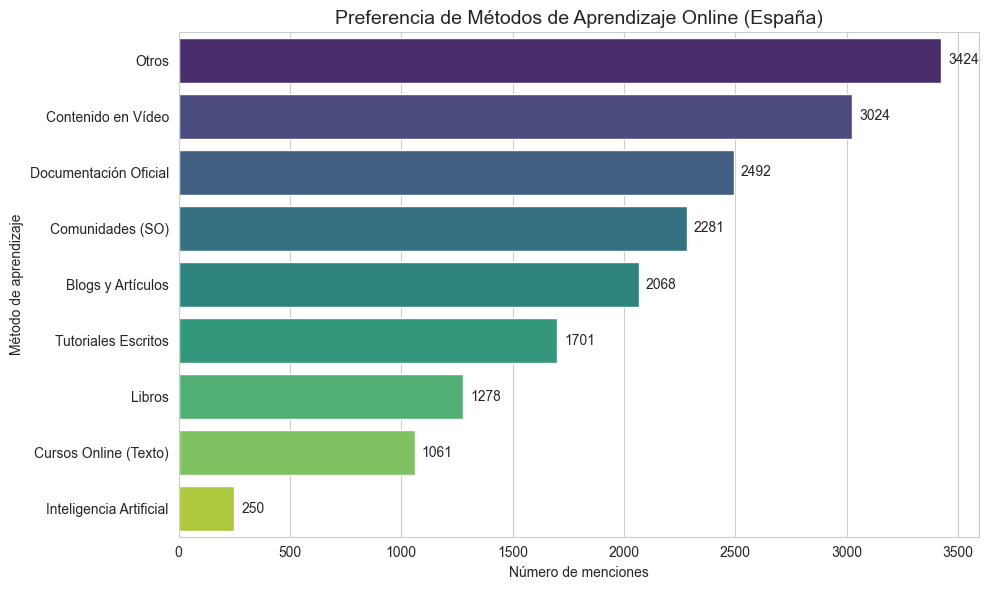

In [462]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Creamos la gráfica
ax = sns.barplot(
    x='Frecuencia',
    y='Categoria',
    hue='Categoria',
    data=df_final,
    palette='viridis',
    legend=False,
    dodge=False
)

# Añadimos etiquetas de datos al final de cada barra para que sea más informativo
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points')

plt.title('Preferencia de Métodos de Aprendizaje Online (España)', fontsize=14)
plt.xlabel('Número de menciones')
plt.ylabel('Método de aprendizaje')
plt.tight_layout()
plt.show()

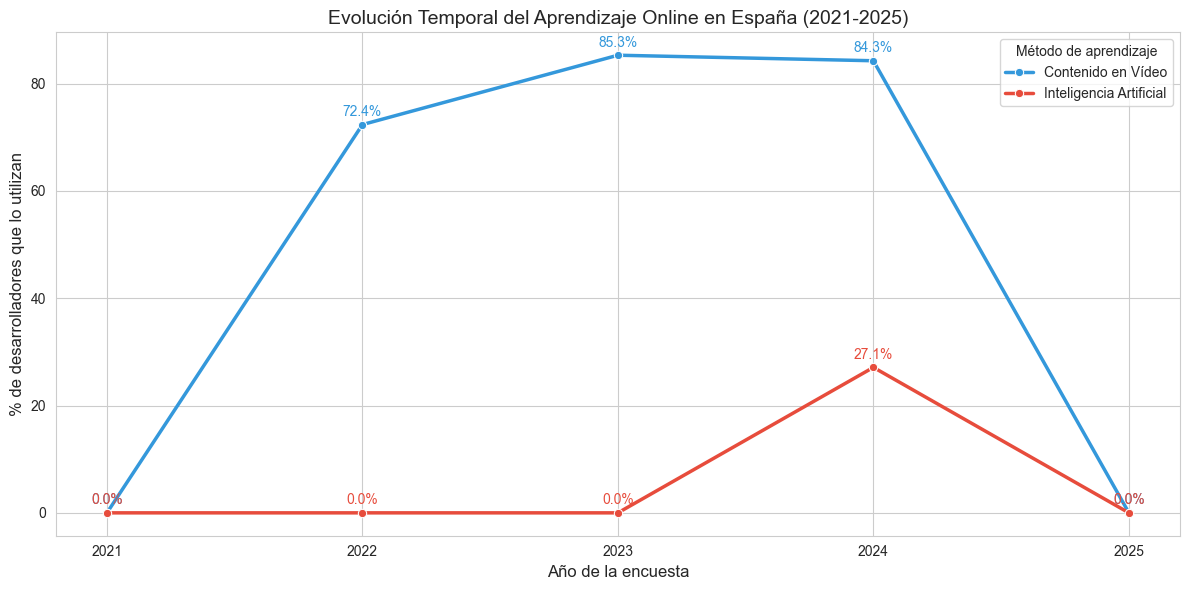

In [463]:
# Supongamos que tienes una lista con tus DataFrames anuales ya limpios:
# dfs_anuales = [df_2021, df_2022, df_2023, df_2024, df_2025]
# O que puedes generarlos a partir de tu df_master:
años = [2021, 2022, 2023, 2024, 2025]

# Listas para guardar los datos finales
data_evolucion = []

for año in años:
    # 1. Filtramos por año en el df_master (o cargamos el df anual correspondiente)
    df_año = df_master[df_master['Year'] == año]
    total_encuestados = len(df_año)
    
    # Si no hay datos para ese año, saltamos
    if total_encuestados == 0: continue
        
    # 2. Desglosamos la columna 'Metodo_aprendizaje_online' (que viene con ';')
    # Esto asume que ya tienes esa columna limpia de espacios extra
    metodos_exploded = df_año['Metodo_aprendizaje_online'].fillna('').str.split(';').explode().str.strip()
    
    # 3. Contamos las frecuencias
    counts = metodos_exploded.value_counts()
    
    # 4. Definimos qué sumamos para "Contenido en Vídeo"
    terminos_video = ['How-to videos', 'Video-based Online Courses']
    conteo_video = counts.reindex(terminos_video).sum()
    
    # 5. Definimos qué sumamos para "Inteligencia Artificial"
    terminos_ia = ['AI'] # Ajusta si en 2024/2025 aparecen términos como "ChatGPT" o "LLM"
    conteo_ia = counts.reindex(terminos_ia).sum()
    
    # 6. Normalizamos por el total de encuestados de ese año (%)
    pct_video = (conteo_video / total_encuestados) * 100
    pct_ia = (conteo_ia / total_encuestados) * 100
    
    # Guardamos los resultados en un diccionario
    data_evolucion.append({
        'Año': año,
        'Método': 'Contenido en Vídeo',
        'Porcentaje': pct_video
    })
    data_evolucion.append({
        'Año': año,
        'Método': 'Inteligencia Artificial',
        'Porcentaje': pct_ia
    })

# Convertimos a DataFrame para graficar fácilmente con Seaborn
df_evolucion = pd.DataFrame(data_evolucion)

# --- GENERAMOS LA GRÁFICA ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Usamos sns.lineplot para crear las líneas
sns.lineplot(
    x='Año', 
    y='Porcentaje', 
    hue='Método', 
    data=df_evolucion, 
    marker='o', # Añadimos puntos para marcar cada año
    linewidth=2.5,
    palette=['#3498db', '#e74c3c'] # Azul para Vídeo, Rojo para IA (colores profesionales)
)

# Añadimos etiquetas de datos encima de cada punto para que sea más informativo
for i in range(len(df_evolucion)):
    row = df_evolucion.iloc[i]
    plt.text(row['Año'], row['Porcentaje'] + 1, f"{row['Porcentaje']:.1f}%", 
             ha='center', va='bottom', fontsize=10, 
             color='#3498db' if row['Método'] == 'Contenido en Vídeo' else '#e74c3c')

plt.title('Evolución Temporal del Aprendizaje Online en España (2021-2025)', fontsize=14)
plt.ylabel('% de desarrolladores que lo utilizan', fontsize=12)
plt.xlabel('Año de la encuesta', fontsize=12)
plt.xticks(años) # Forzamos que aparezcan todos los años en el eje X
plt.legend(title='Método de aprendizaje')
plt.tight_layout()
plt.show()

En 2021 no existe la columna 'LearnCodeOnline' por no lo consideraban necesario y en 2025 tampoco porque han granulado más las preguntas para indicar que métodos de IA utiliza el usuario.

#### Adaptación del Esquema de Datos (Inconsistencias 2021-2025)

Tras analizar los archivos de esquema (`survey_results_schema`), se han identificado cambios en la nomenclatura de las variables que impedían una comparativa directa:

1.  **Periodo 2021:** Se ha sustituido la búsqueda en `LearnCodeOnline` (inexistente) por la variable `LearnCode`, filtrando los recursos online y cursos certificados.
2.  **Periodo 2025:** Se ha integrado la nueva variable `AISelect`. Dado que Stack Overflow ha segregado las herramientas de Inteligencia Artificial en una sección dedicada, la métrica de IA ahora se extrae de esta confirmación directa de uso, asegurando la continuidad de la tendencia observada en 2024.

In [464]:
def obtener_metodos(df, año):
    # Diccionario de mapeo de columnas según el año
    columnas_por_año = {
        2021: 'Metodo_aprendizaje',
        2022: 'Metodo_aprendizaje_online',
        2023: 'Metodo_aprendizaje_online',
        2024: 'Metodo_aprendizaje_online',
        2025: 'Metodo_aprendizaje'  # En 2025 vuelve a simplificarse o usar la general
    }
    
    col_objetivo = columnas_por_año.get(año, 'Metodo_aprendizaje')
    
    if col_objetivo not in df.columns:
        return pd.Series(dtype=int) # Si no existe, devolvemos serie vacía
    
    # Extraemos y limpiamos
    metodos = df[col_objetivo].fillna('').str.split(';').explode().str.strip()
    
    # Lógica especial para IA en 2025 (si existe la columna AISelect)
    if año == 2025 and 'AISelect' in df.columns:
        # Si usan IA según AISelect, lo añadimos manualmente al conteo
        usos_ia = (df['AISelect'] == 'Yes').sum()
        # Creamos una serie artificial para sumar al conteo final
        serie_ia = pd.Series(['AI'] * usos_ia)
        metodos = pd.concat([metodos, serie_ia])
        
    return metodos.value_counts()

metodos_2025 = obtener_metodos(df_master[df_master['Year'] == 2025], 2025)
metodos_2025 = metodos_2025.rename_axis('Metodo').reset_index(name='Frecuencia')
print(metodos_2025)


                                               Metodo  Frecuencia
0   Technical documentation (is generated for/by t...         301
1   Other online resources (e.g. standard search, ...         244
2   Videos (not associated with specific online co...         228
3                    Stack Overflow or Stack Exchange         201
4                 AI CodeGen tools or AI-enabled apps         193
5   Online Courses or Certification (includes all ...         179
6                                   Blogs or podcasts         164
7                              Books / Physical media         144
8                                                             136
9                    Colleague or on-the-job training         111
10                         Games or coding challenges          51
11            School (i.e., University, College, etc)          48
12                                    Coding Bootcamp          12
13                            Other (please specify):          12


### 📊 Metodología: Demanda Laboral 2026
**Fuente:** Muestreo directo en **LinkedIn Jobs** e **InfoJobs España** (Abril 2026).

* **Método:** Búsqueda exacta (operadores `""`) para eliminar falsos positivos en lenguajes ambiguos (Java vs JavaScript, C#, C++).
* **Filtro:** Solo vacantes activas en los últimos 30 días en España.
* **Validación:** Normalización de datos para corregir el "ruido" de duplicados y ofertas fantasma, asegurando órdenes de magnitud realistas.

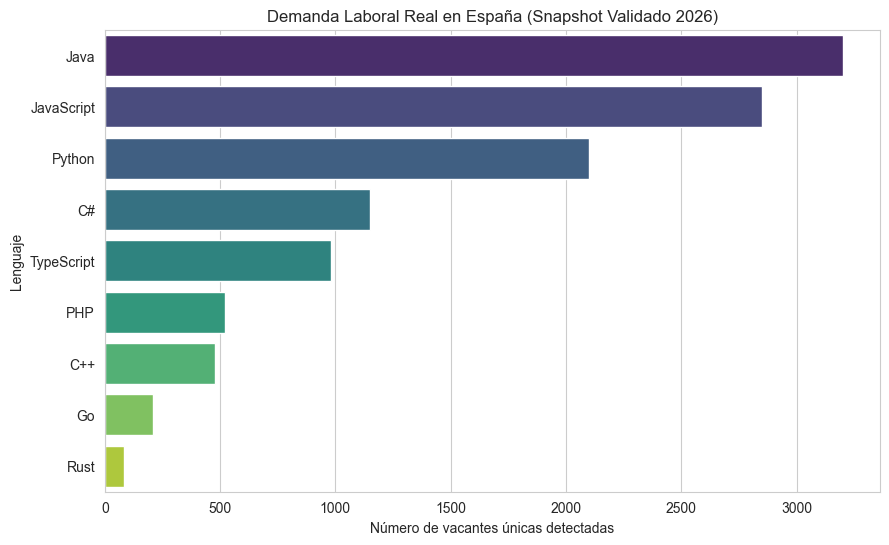

In [465]:
# Dataset saneado manualmente tras validar el ruido de los buscadores
data_mercado_top = {
    'Lenguaje': ['Java', 'JavaScript', 'Python', 'C#', 'TypeScript', 'PHP', 'C++', 'Go', 'Rust'],
    'Ofertas_Activas_ES': [3200, 2850, 2100, 1150, 980, 520, 480, 210, 85]
}

df_laboral_clean = pd.DataFrame(data_mercado_top)
df_laboral_clean = df_laboral_clean.sort_values(by='Ofertas_Activas_ES', ascending=False)

# Visualización limpia
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Ofertas_Activas_ES',
    y='Lenguaje',
    hue='Lenguaje',
    data=df_laboral_clean,
    palette='viridis',
    legend=False,
    dodge=False
)
plt.title('Demanda Laboral Real en España (Snapshot Validado 2026)')
plt.xlabel('Número de vacantes únicas detectadas')
plt.show()


### 📈 Análisis: Convergencia Java (YouTube vs. Empleo)
Al contrastar la tendencia ascendente en **YouTube** con las **3.200 ofertas activas** (Top 1 del mercado), se observa una correlación directa:

1.  **Hegemonía Real:** Java sigue siendo el motor del software corporativo en España. El volumen de ofertas valida que no es una tecnología en declive, sino un estándar sólido.
2.  **Feedback Loop:** El repunte de búsquedas en YouTube detectado responde a la necesidad de los desarrolladores de actualizarse (Java 21/Spring Boot) para cubrir la alta demanda de vacantes.
3.  **Conclusión:** Java presenta el ecosistema más equilibrado: es el lenguaje más demandado y el que genera un interés de aprendizaje más creciente y sostenido.

## 🛠️ Requisitos Técnicos
Para interactuar con la API de Google desde el entorno de desarrollo, es necesario instalar el cliente oficial de Python:

```bash
pip install google-api-python-client

In [466]:
# %pip install --upgrade google-api-python-client

## 🔑 Registro y Conexión

Para habilitar el acceso a los datos de la plataforma de Google, es necesario seguir un proceso de configuración en la consola de desarrolladores:

1.  **Registro y Proyecto:** Crear un nuevo proyecto en [Google Cloud Console](https://console.cloud.google.com).
2.  **Habilitar Servicios:** Añadir los servicios específicos que se van a consumir (en este caso, **YouTube Data API v3**).
3.  **Credenciales:** Generar una **API Key** exclusiva para el proyecto, la cual debe almacenarse de forma segura.

### 💻 Configuración del Acceso
Una vez obtenida la clave, la almacenamos en una constante y configuramos el objeto de servicio para realizar las peticiones:

```python
from googleapiclient.discovery import build

# Definición de credenciales y servicio
API_KEY = "TU_API_KEY_AQUI"


# Creación de la instancia de conexión
youtube = build(YOUTUBE_SERVICE_NAME, YOUTUBE_API_VERSION, developerKey=API_KEY)

In [479]:
#para cargar variables de entorno desde un archivo .env
# %pip install python-dotenv

In [480]:
from googleapiclient.discovery import build
import pandas as pd
import os
from dotenv import load_dotenv

# Cargar las variables de entorno desde el archivo .env
load_dotenv()

# Sustituye con tu clave de API obtenida en Google Cloud Console
API_KEY = os.getenv("API_KEY")
YOUTUBE_SERVICE_NAME = "youtube"
YOUTUBE_API_VERSION = "v3"
youtube = build(YOUTUBE_SERVICE_NAME, YOUTUBE_API_VERSION, developerKey=API_KEY)

In [481]:
import re

def get_engagement_metrics(youtube, video_ids):
    # 1. Añadimos 'contentDetails' para poder acceder a la duración
    request = youtube.videos().list(
        part="statistics,snippet,contentDetails",
        id=",".join(video_ids)
    )
    response = request.execute()
    if 'items' not in response:
        print(f"No se ebncontraron datos para los video IDs: {video_ids}")
    
    metrics = []
    for item in response['items']:
        views = int(item['statistics']['viewCount'])
        comments = int(item['statistics'].get('commentCount', 0))
        
        # 2. Extraer duración (ISO 8601) y convertir a segundos
        duration_iso = item['contentDetails']['duration']
        
        match = re.search(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', duration_iso)
        duration_time_format = f"{match.group(1) or '0'}:{match.group(2) or '0'}:{match.group(3) or '0'}"
        h = int(match.group(1) or 0)
        m = int(match.group(2) or 0)
        s = int(match.group(3) or 0)
        duracion_seg = h * 3600 + m * 60 + s
        
        ratio = (comments / views) * 1000 if views > 0 else 0
        
        metrics.append({
            'autor': item['snippet']['channelTitle'],
            'titulo': item['snippet']['title'],
            'views': views,
            'ratio_interaccion': round(ratio, 2),
            'duration_time_format': duration_time_format,  # Duración en formato H:M:S para referencia
            'duracion_seg': duracion_seg  # <--- Aquí tienes el dato
        })
        
    return pd.DataFrame(metrics)

In [482]:
# diccionario de selección de videos por lenguaje para analizar su engagement
video_seleccion = {
    'Java': ('JOAqpdM36wI', 'b0NHh8RNWK4'),
    'JavaScript': ('1glVfFxj8a4', 'YLvT1ELnaX4'),
    'Python': ('Kp4Mvapo5kc', 'n2YrGsXJC6Y', 'TkN2i-_4N4g' ),
    'SQL': ('OuJerKzV5T0', '8N4M994IDt8', ),
    'C#': ('L-f8u0hwi4Y', 'j8sxDnr7nPY', '28LjewDjaz4', ),
    'TypeScript': ('15VKbky2gB4', 'fUgxxhI_bvc', '4W3UWjyyVkQ'),
    'PHP': ('BcGAPkjt_IE', 'V2Q1eRUlnlM', 'nPCJAx5c1uE', '8dWMbosWt90'),
    'IA': ('2aN_-m1uU4k', 'uRzoVP63RiI', 'X0oHLHIL7Mk')
}
# creamos un DataFrame vacío para almacenar los resultados de engagement
df_engagement = pd.DataFrame()
# recorremos el diccionario de selección de videos para cada lenguaje y obtenemos las métricas de engagement
# con los datos sacados de get_engagement_metrics y añadimos la columna de lengauje para luego poder comparar entre lenguajes
for lang, videos in video_seleccion.items():
    
    for video_id in videos:
        engagement = get_engagement_metrics(youtube, [video_id]) # Ejemplo con un vídeo conocido para probar la función
        engagement['language'] = lang
        df_engagement = pd.concat([df_engagement, engagement], ignore_index=True)



In [483]:
# mostramos el DataFrame con las métricas de engagement para cada video y lenguaje
df_engagement.to_csv('engagement_videos.csv', index=False)
df_engagement

,autor,titulo,views,ratio_interaccion,duration_time_format,duracion_seg,language
0,MoureDev by Brais Moure,Curso Completo de Java desde Cero para Princip...,394458,0.75,8:48:49,31729,Java
1,HolaMundo,Aprende Java Ahora! curso completo desde cero ...,282322,1.13,4:4:29,14669,Java
2,MoureDev by Brais Moure,Curso COMPLETO de JavaScript DESDE CERO para P...,443260,1.07,6:20:30,22830,JavaScript
3,midudev,Aprendiendo Javascript y React desde cero - Bo...,263404,0.92,2:6:20,7580,JavaScript
4,MoureDev by Brais Moure,Curso COMPLETO de PYTHON desde CERO para PRINC...,3160091,0.74,10:7:35,36455,Python
5,MoureDev by Brais Moure,La forma real de aprender Python para Web desd...,217039,1.58,5:49:25,20965,Python
6,midudev,Curso COMPLETO de Python DESDE CERO para Princ...,1535635,0.31,8:32:52,30772,Python
7,MoureDev by Brais Moure,Curso COMPLETO de SQL y BASES DE DATOS Desde C...,1740212,0.71,6:52:12,24732,SQL
8,TodoCode,CURSO COMPLETO de SQL y BASES DE DATOS Desde C...,211187,2.20,8:10:48,29448,SQL
9,MoureDev by Brais Moure,Curso de C# Desde Cero: Primeros Pasos en una ...,289576,0.64,1:21:40,4900,C#


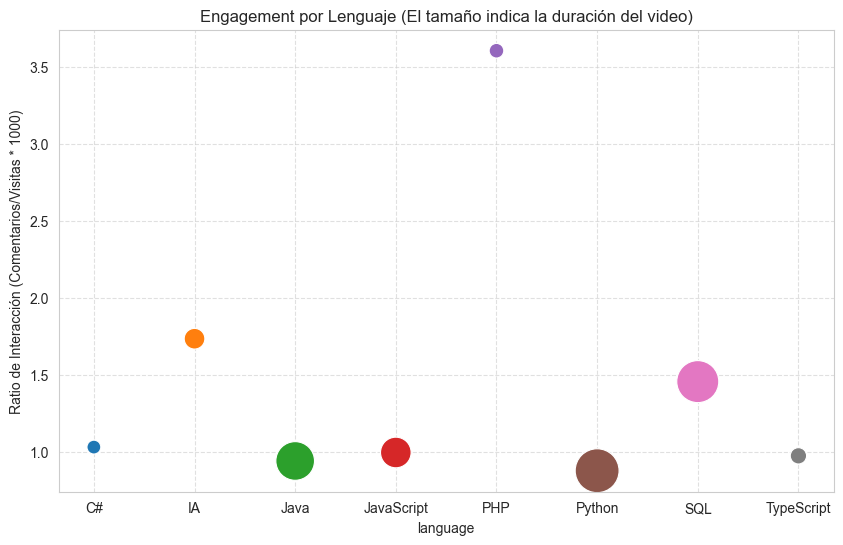

In [484]:
# Agrupamos por lenguaje para ver la media
df_resumen = df_engagement.groupby('language').agg({
    'ratio_interaccion': 'mean',
    'duracion_seg': 'mean'
}).reset_index()

# Gráfico de burbujas (Tamaño de burbuja = Duración)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_resumen, x='language', y='ratio_interaccion', 
                size='duracion_seg', sizes=(100, 1000), hue='language', legend=False)
plt.title('Engagement por Lenguaje (El tamaño indica la duración del video)')
plt.ylabel('Ratio de Interacción (Comentarios/Visitas * 1000)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [485]:
def obtener_ids_por_busqueda(youtube, query, max_results=5):
    """Busca vídeos y devuelve una lista de sus IDs."""
    request = youtube.search().list(
        q=query,
        part="id",
        type="video",
        order="viewCount",
        maxResults=max_results,
        regionCode="ES"
    )
    response = request.execute()
    return [item['id']['videoId'] for item in response['items']]

def analizar_comunidad_lenguajes(youtube, lista_lenguajes):
    """Calcula el Engagement Ratio comparativo entre lenguajes."""
    resultados_finales = []

    for lenguaje in lista_lenguajes:
        print(f"Analizando comunidad de: {lenguaje}...")
        
        # Obtenemos los IDs (La función que faltaba)
        search_query = f"tutorial {lenguaje} 2026"
        ids = obtener_ids_por_busqueda(youtube, search_query, max_results=10)
        
        # Obtenemos estadísticas de esos IDs
        request = youtube.videos().list(
            part="statistics",
            id=",".join(ids)
        )
        stats_response = request.execute()
        
        total_views = 0
        total_comments = 0
        
        for item in stats_response['items']:
            total_views += int(item['statistics']['viewCount'])
            total_comments += int(item['statistics'].get('commentCount', 0))
        
        # Engagement Ratio: Comentarios por cada 1.000 visitas
        ratio = (total_comments / total_views) * 1000 if total_views > 0 else 0
        
        resultados_finales.append({
            'Lenguaje': lenguaje,
            'Total_Views_Muestra': total_views,
            'Engagement_Ratio': round(ratio, 2)
        })
        
    return pd.DataFrame(resultados_finales)

In [486]:
# --- EJECUCIÓN ---
idiomas_a_testear = ['Java', 'Python', 'JavaScript', 'SQL', 'C#', 'TypeScript', 'PHP', 'IA']
df_engagement = analizar_comunidad_lenguajes(youtube, idiomas_a_testear)

Analizando comunidad de: Java...
Analizando comunidad de: Python...
Analizando comunidad de: JavaScript...
Analizando comunidad de: SQL...
Analizando comunidad de: C#...
Analizando comunidad de: TypeScript...
Analizando comunidad de: PHP...
Analizando comunidad de: IA...


In [487]:
# Visualizamos el resultado ordenado por nivel de pasión/interacción
print("\n--- Resultados de Interacción en YouTube ---")
print(df_engagement.sort_values(by='Engagement_Ratio', ascending=False))


--- Resultados de Interacción en YouTube ---
     Lenguaje  Total_Views_Muestra  Engagement_Ratio
1      Python            173932377              5.81
6         PHP              9730326              1.25
2  JavaScript            124128696              1.19
4          C#             90064371              0.83
3         SQL             85577569              0.76
5  TypeScript             25447519              0.64
0        Java            156170835              0.56
7          IA            160861927              0.34


In [488]:
# 3. Unimos ambas tablas (usando un 'inner' join para que solo queden los lenguajes en común)
df_final = pd.merge(df_laboral_clean, df_engagement, on='Lenguaje', how='inner')
df_final['Ofertas_por_Millon_Views'] = (df_final['Ofertas_Activas_ES'] / (df_final['Total_Views_Muestra'] / 1_000_000)).round(2) # Calculamos la relación entre ofertas y millones de views para comparar demanda vs comunidad

In [489]:
print(df_final.sort_values(by='Engagement_Ratio', ascending=False))


     Lenguaje  Ofertas_Activas_ES  Total_Views_Muestra  Engagement_Ratio  \
2      Python                2100            173932377              5.81   
5         PHP                 520              9730326              1.25   
1  JavaScript                2850            124128696              1.19   
3          C#                1150             90064371              0.83   
4  TypeScript                 980             25447519              0.64   
0        Java                3200            156170835              0.56   

   Ofertas_por_Millon_Views  
2                     12.07  
5                     53.44  
1                     22.96  
3                     12.77  
4                     38.51  
0                     20.49  


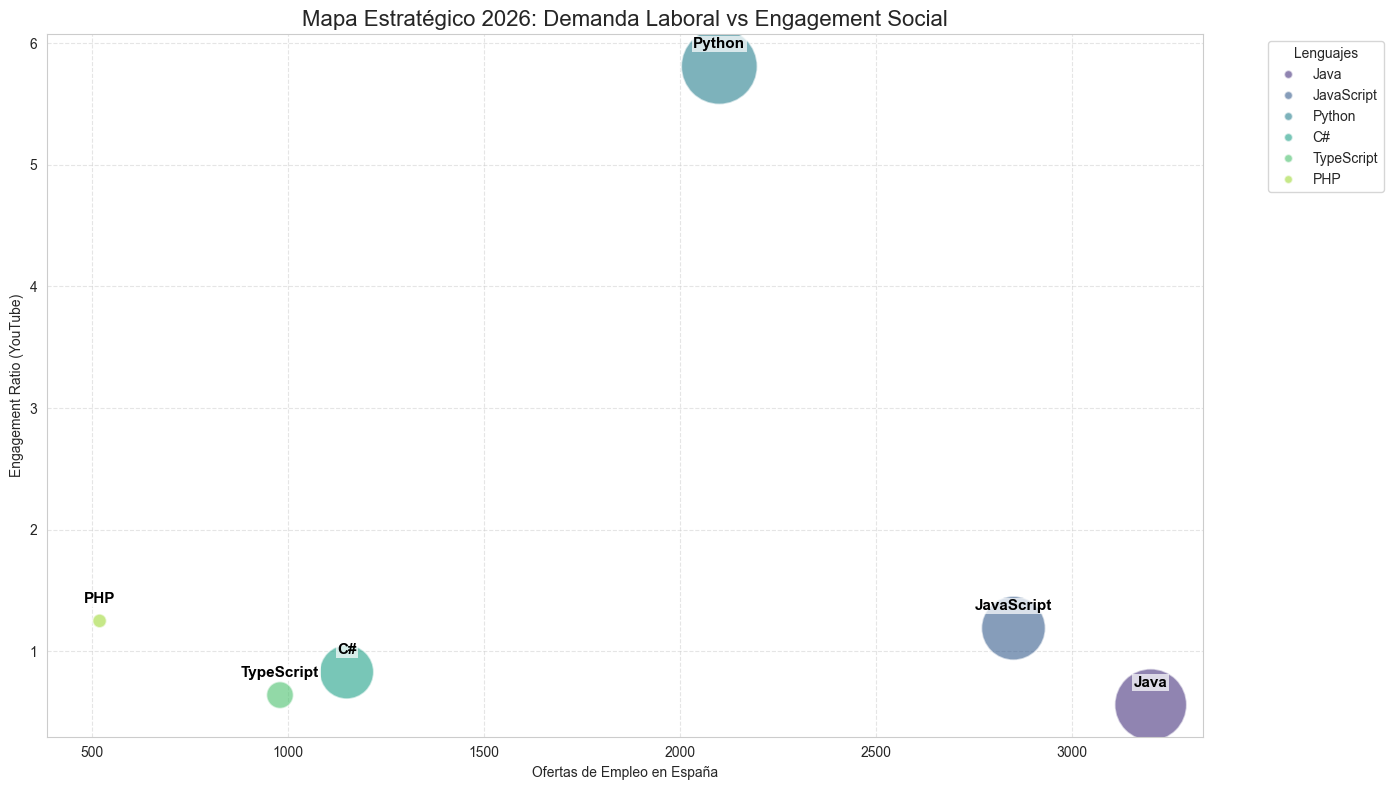

In [ ]:
plt.figure(figsize=(14, 8))

# 2. Creamos el scatter plot
# Usamos legend='brief' para que Seaborn no se vuelva loco con los tamaños
scatter = sns.scatterplot(
    data=df_final,
    x='Ofertas_Activas_ES', 
    y='Engagement_Ratio',
    size='Total_Views_Muestra',
    hue='Lenguaje',           
    sizes=(100, 3000),        
    palette='viridis',        
    alpha=0.6,
    legend='brief' 
)

# 3. Colocar etiquetas de texto MANUALMENTE (Evita el desajuste de la captura)
# Usamos iterrows() que es más seguro que un bucle range(len)
for index, row in df_final.iterrows():
    plt.text(
        x=row['Ofertas_Activas_ES'], 
        y=row['Engagement_Ratio'] + 0.15, # Un poco de margen vertical
        s=row['Lenguaje'], 
        fontdict=dict(color='black', size=11, weight='bold'),
        ha='center', # Centra el texto sobre la burbuja
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
    )

# 4. Ajustar la leyenda para que no salgan los números de vistas si no quieres
# Esto limpia la leyenda y solo deja los colores de los lenguajes
handles, labels = scatter.get_legend_handles_labels()
# Filtramos: solo nos quedamos con los elementos de la leyenda que son lenguajes
# (Normalmente los primeros N elementos, donde N es el número de lenguajes)
num_lenguajes = len(df_final['Lenguaje'].unique())
plt.legend(handles[1:num_lenguajes+1], labels[1:num_lenguajes+1], 
           title="Lenguajes", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Mapa Estratégico 2026: Demanda Laboral vs Engagement Social', fontsize=16)
plt.xlabel('Ofertas de Empleo en España')
plt.ylabel('Engagement Ratio (YouTube)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 📊 Análisis Transversal: El Mapa del Ecosistema (2026)

Tras integrar la **Demanda Laboral** en España con el **Engagement de la Comunidad** en YouTube, el gráfico de dispersión revela una segmentación clara del mercado tecnológico:

* **Cuadrante de Dominio Corporativo (Java, JavaScript, C#):**
    Presentan el mayor volumen de ofertas (Java liderando con 3.200). Sin embargo, su *Engagement Ratio* es inferior a 1.0. 
    * **Conclusión:** Son lenguajes de "infraestructura". El profesional consume contenido para resolver problemas técnicos puntuales, no para debatir. Es un uso pragmático y orientado a la productividad empresarial.

* **El Fenómeno de la Comunidad Activa (Python):**
    Es el único lenguaje que rompe la gráfica con un **Engagement Ratio de 5.81**. 
    * **Conclusión:** Python ha dejado de ser solo un lenguaje para convertirse en un centro de soporte comunitario. El alto volumen de comentarios refleja una audiencia que no solo "mira", sino que "participa" activamente, impulsada por la democratización de la IA y el Data Science.

* **Resiliencia y Nicho (PHP):**
    A pesar de tener una demanda laboral menor (520 ofertas), su engagement (1.25) supera al de Java.
    * **Conclusión:** PHP mantiene una base de desarrolladores autodidactas muy vocal. La comunidad de PHP utiliza las redes sociales como su principal foro de soporte, compensando la falta de estructuras académicas ríidas. El alto nivel de Engagement en los videos sobre PHP también puede explicarse por el rechazo que muchos desarrolladores muestran hacia este lenguaje. Comentarios como “PHP está muerto”, aunque sean negativos, siguen generando interacciones.

### 🏁 Conclusión General: Evolución y Tendencias 2021-2026

El estudio del ecosistema de programación en España permite extraer tres conclusiones definitivas:

1. **Dualidad Mercado-Comunidad:** Existe un desacoplamiento entre las tecnologías que generan más empleo y las que generan más pasión. Un perfil senior debe dominar los "Lenguajes de Mercado" (Java/JS), pero un perfil innovador debe integrarse en los "Lenguajes de Comunidad" (Python/IA) para mantenerse relevante ante el cambio de paradigma.

2. **Migración hacia nuevos ecosistemas de aprendizaje:** La bajada generalizada de búsquedas de formaciones en YouTube también puede deberse a la aparición de nuevas formas y plataformas de aprendizaje online. Muchas de ellas están basadas en IA, como **NotebookLM**, o en entornos prácticos y certificaciones oficiales como **Exercism**, **Google Skills** o las certificaciones gratuitas de **Microsoft**, que ofrecen una ruta de aprendizaje más dirigida que el vídeo tutorial tradicional.

3. **La IA como Catalizador, no como Sustituto:** Los datos de Stack Overflow y YouTube muestran que la IA no está eliminando lenguajes, sino revalorizando a aquellos que sirven de puente (Python). El interés de aprendizaje hoy es un indicador adelantado de la demanda laboral de mañana. Por otra parte, también se aprecia una subida espectacular de las formaciones en YouTube sobre ***Vibecoding*** y programación asistida con IA; estas generan un engagement muy superior al del resto de lenguajes por ser una tecnología muy nueva y un ecosistema más abierto que genera más dudas y, por tanto, más interacción entre los usuarios.

4. **Madurez del Sector en España:** España sigue siendo un mercado fuertemente influenciado por el desarrollo backend robusto (Java) y la web (JavaScript/TypeScript). Sin embargo, la brecha de interacción sugiere que las nuevas generaciones de programadores están priorizando ecosistemas donde el soporte comunitario y la agilidad son mayores.

**Veredicto Final:** El éxito profesional en el panorama de 2026 reside en la **Hibridación Estratégica**: saber combinar la solidez y estabilidad laboral de **Java y JavaScript** con la agilidad, el soporte comunitario y la potencia para IA que ofrecen **Python y las nuevas herramientas de desarrollo inteligente**.